# CLTV Prediction — AV Data Scientist Hiring Hackathon

## i. Objective
Predict Customer Lifetime Value (CLTV) as a regression problem. Metric: R² on original scale.

## ii. Pipeline
| Stage | Description |
|---|---|
| 1. EDA | Target distribution, outlier analysis, bivariate plots |
| 2. Feature Engineering | Ordinal encoding, zero-inflation handling, interactions, target encoding |
| 3. Modeling | LightGBM + XGBoost + CatBoost with 5-Fold OOF CV |
| 4. Ensemble | Scipy-optimized weighted blend on OOF R² |

## iii. Key Libraries
- **Boosting:** LightGBM, XGBoost, CatBoost  
- **Validation:** sklearn KFold, R² metric  
- **Optimization:** scipy.optimize

# **1. Import Libraries**

In [224]:
%%time

#Load Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import KFold
from sklearn.metrics import r2_score

import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostRegressor

sns.set_theme(style='darkgrid')
plt.rcParams.update({'figure.dpi': 120})

import matplotlib.ticker as mticker
from scipy import stats

sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
})
CLTV_COLOR  = '#4C72B0'
ALERT_COLOR = '#DD8452'
print('Setup done.')

Setup done.
CPU times: user 3.95 ms, sys: 1.99 ms, total: 5.94 ms
Wall time: 6.63 ms


# **2. Load Data**

In [225]:
%%time

train_df = pd.read_csv(r'/home/bane/contest/Analytics_vidhya/train.csv')
test_df = pd.read_csv(r'/home/bane/contest/Analytics_vidhya/test.csv')

train_df


CPU times: user 195 ms, sys: 22.2 ms, total: 217 ms
Wall time: 224 ms


,id,gender,area,qualification,income,marital_status,vintage,claim_amount,num_policies,policy,type_of_policy,cltv
0,1,Male,Urban,Bachelor,5L-10L,1,5,5790,More than 1,A,Platinum,64308
1,2,Male,Rural,High School,5L-10L,0,8,5080,More than 1,A,Platinum,515400
2,3,Male,Urban,Bachelor,5L-10L,1,8,2599,More than 1,A,Platinum,64212
3,4,Female,Rural,High School,5L-10L,0,7,0,More than 1,A,Platinum,97920
4,5,Male,Urban,High School,More than 10L,1,6,3508,More than 1,A,Gold,59736
...,...,...,...,...,...,...,...,...,...,...,...,...
89387,89388,Male,Rural,High School,More than 10L,0,6,0,More than 1,B,Platinum,95736
89388,89389,Male,Urban,Bachelor,5L-10L,1,0,3897,More than 1,A,Platinum,67596
89389,89390,Female,Urban,Bachelor,5L-10L,0,4,3363,More than 1,B,Platinum,114120
89390,89391,Female,Rural,High School,2L-5L,0,8,0,More than 1,B,Platinum,71772


# **3. Data Inspection & Preprocessing**

In [226]:
# Data Inspection
print(f"Train Shape : {train_df.shape}")
train_df.info()

Train Shape : (89392, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 89392 entries, 0 to 89391
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   id              89392 non-null  int64 
 1   gender          89392 non-null  object
 2   area            89392 non-null  object
 3   qualification   89392 non-null  object
 4   income          89392 non-null  object
 5   marital_status  89392 non-null  int64 
 6   vintage         89392 non-null  int64 
 7   claim_amount    89392 non-null  int64 
 8   num_policies    89392 non-null  object
 9   policy          89392 non-null  object
 10  type_of_policy  89392 non-null  object
 11  cltv            89392 non-null  int64 
dtypes: int64(5), object(7)
memory usage: 8.2+ MB


In [227]:
print("-- Data Types --")
print(train_df.dtypes)
print("-- Missing Values -- ")
print(train_df.isnull().sum())

-- Data Types --
id                 int64
gender            object
area              object
qualification     object
income            object
marital_status     int64
vintage            int64
claim_amount       int64
num_policies      object
policy            object
type_of_policy    object
cltv               int64
dtype: object
-- Missing Values -- 
id                0
gender            0
area              0
qualification     0
income            0
marital_status    0
vintage           0
claim_amount      0
num_policies      0
policy            0
type_of_policy    0
cltv              0
dtype: int64


In [228]:
train_df.isnull().sum()/train_df.shape[0]*100
#checks the percentage missing of value if exist

id                0.0
gender            0.0
area              0.0
qualification     0.0
income            0.0
marital_status    0.0
vintage           0.0
claim_amount      0.0
num_policies      0.0
policy            0.0
type_of_policy    0.0
cltv              0.0
dtype: float64

In [229]:
# Removing the unnecessary columns
train_df.drop(columns=["id"], inplace=True) 
train_df

,gender,area,qualification,income,marital_status,vintage,claim_amount,num_policies,policy,type_of_policy,cltv
0,Male,Urban,Bachelor,5L-10L,1,5,5790,More than 1,A,Platinum,64308
1,Male,Rural,High School,5L-10L,0,8,5080,More than 1,A,Platinum,515400
2,Male,Urban,Bachelor,5L-10L,1,8,2599,More than 1,A,Platinum,64212
3,Female,Rural,High School,5L-10L,0,7,0,More than 1,A,Platinum,97920
4,Male,Urban,High School,More than 10L,1,6,3508,More than 1,A,Gold,59736
...,...,...,...,...,...,...,...,...,...,...,...
89387,Male,Rural,High School,More than 10L,0,6,0,More than 1,B,Platinum,95736
89388,Male,Urban,Bachelor,5L-10L,1,0,3897,More than 1,A,Platinum,67596
89389,Female,Urban,Bachelor,5L-10L,0,4,3363,More than 1,B,Platinum,114120
89390,Female,Rural,High School,2L-5L,0,8,0,More than 1,B,Platinum,71772


In [230]:
train_df.describe().T.style.background_gradient(cmap='Blues', subset=['mean', 'std', 'max'])

,count,mean,std,min,25%,50%,75%,max
marital_status,89392.000000,0.575488,0.494272,0.000000,0.000000,1.000000,1.000000,1.000000
vintage,89392.000000,4.595669,2.290446,0.000000,3.000000,5.000000,6.000000,8.000000
claim_amount,89392.000000,4351.502416,3262.359775,0.000000,2406.000000,4089.000000,6094.000000,31894.000000
cltv,89392.000000,97952.828978,90613.814793,24828.000000,52836.000000,66396.000000,103440.000000,724068.000000


## Target Variable Analysis - 'cltv'

In [231]:
cltv = train_df['cltv'] #Initializing Target variable
print(f"#### cltv statistics ####")
print(f"Mean : {cltv.mean():,.0f}")
print(f"Median : {cltv.median():,.0f}")
print(f"Std : {cltv.std():,.0f}")
print(f"Min : {cltv.min():,.0f}")
print(f"Max : {cltv.max():,.0f}")
print(f"Skewness : {cltv.skew():,.0f}")
print(f"Kutosis : {cltv.kurt():,.0f}")
print(f"p25/p75 : {cltv.quantile(0.25):,.0f} / {cltv.quantile(0.75):,.0f}")
print(f"IQR : {cltv.quantile(0.75) - cltv.quantile(0.25):,.0f}")

#### cltv statistics ####
Mean : 97,953
Median : 66,396
Std : 90,614
Min : 24,828
Max : 724,068
Skewness : 3
Kutosis : 8
p25/p75 : 52,836 / 103,440
IQR : 50,604


**Observation :** 
- Here we can easily see ***Mean == 97k+***, ***Standard Deviation(std) == 90k+*** and ***Max == 724k+***
- The ***Standard Deviation*** is almost equal to ***mean***, which indicates the high variability in the data.
- The ***Maximum value(724k)*** is extremely far from the mean and even from the 75th percentile(~103k), clearly indicate the presence of outliers.
- The ***mean is significantly higher than the median (66k)***, confirming that the distribution is ***positively skewed (right-skewed)***
- The ***Skewness (~3)*** further supports the distribution is ***heavily right-skewed*** shows that the small number of customer have high cltv.
- The Kurtosis (~8) indicated the ***heavy tails***, shows that outliers are not just present but impactful.
- From P25(~52k+) and P75(~103k+), we can infer that;
    - The Majority (middle 50%) of customer lie in ***realtively narrow range***
    - While a few customers is ***far beyond this range***, creating imbalance.
- The ***IQR (~50k)*** shows the spread of the central data, when compared with the max values, it highlights how ***extreme the upper tail is.***      

In [232]:
# Cardinality of categoricals 
cat_cols = train_df.select_dtypes('object').columns.tolist()
for col in cat_cols:
    print(f'{col:20s} → {train_df[col].nunique()} unique : {train_df[col].unique().tolist()}')

gender               → 2 unique : ['Male', 'Female']
area                 → 2 unique : ['Urban', 'Rural']
qualification        → 3 unique : ['Bachelor', 'High School', 'Others']
income               → 4 unique : ['5L-10L', 'More than 10L', '2L-5L', '<=2L']
num_policies         → 2 unique : ['More than 1', '1']
policy               → 3 unique : ['A', 'C', 'B']
type_of_policy       → 3 unique : ['Platinum', 'Gold', 'Silver']


# **4. Exploratory Data Analysis (EDA)**

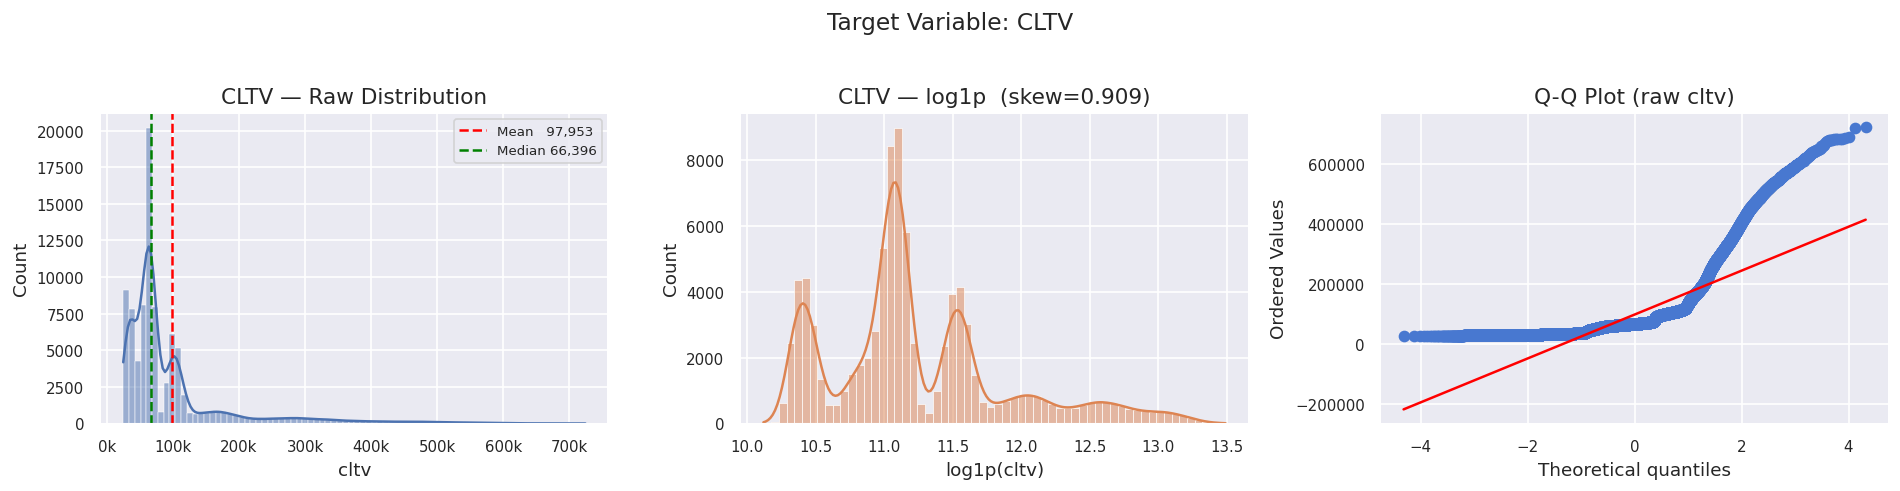


→ Raw skew=2.753 → after log1p skew=0.909  (train on log-transformed target)


In [233]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Raw distribution
sns.histplot(cltv, bins=80, kde=True, color=CLTV_COLOR, ax=axes[0])
axes[0].axvline(cltv.mean(),   color='red',    ls='--', lw=1.5, label=f'Mean   {cltv.mean():,.0f}')
axes[0].axvline(cltv.median(), color='green',  ls='--', lw=1.5, label=f'Median {cltv.median():,.0f}')
axes[0].set_title('CLTV — Raw Distribution')
axes[0].legend(fontsize=8)
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}k'))

# Log1p distribution
log_cltv = np.log1p(cltv)
sns.histplot(log_cltv, bins=60, kde=True, color=ALERT_COLOR, ax=axes[1])
axes[1].set_title(f'CLTV — log1p  (skew={log_cltv.skew():.3f})')
axes[1].set_xlabel('log1p(cltv)')

# Q-Q plot on raw
stats.probplot(cltv, dist='norm', plot=axes[2])
axes[2].set_title('Q-Q Plot (raw cltv)')
axes[2].get_lines()[1].set_color('red')

plt.suptitle('Target Variable: CLTV', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()
print(f'\n→ Raw skew={cltv.skew():.3f} → after log1p skew={log_cltv.skew():.3f}  (train on log-transformed target)')

### **4.1 Outlier Analysis**

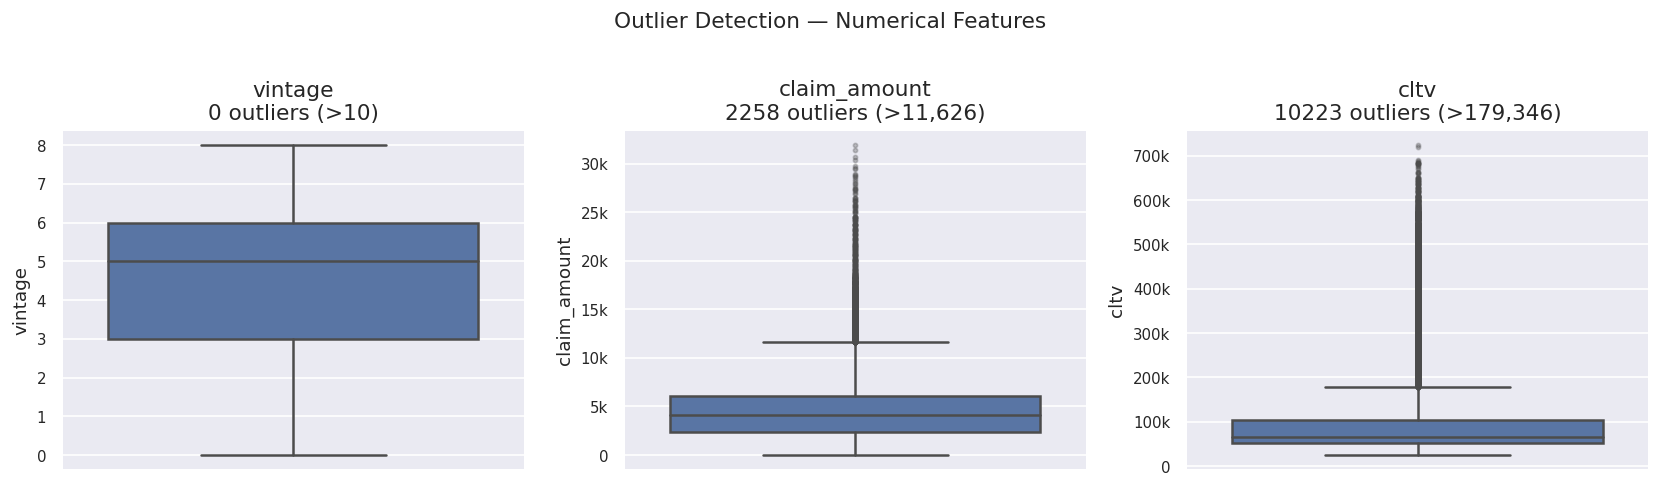

In [234]:
num_cols = ['vintage', 'claim_amount', 'cltv']

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, num_cols):
    sns.boxplot(y=train_df[col], color=CLTV_COLOR, ax=ax, flierprops=dict(marker='.', alpha=0.3))
    q1, q3 = train_df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    upper = q3 + 1.5 * iqr
    n_out = (train_df[col] > upper).sum()
    ax.set_title(f'{col}\n{n_out} outliers (>{upper:,.0f})')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}k' if x >= 1000 else f'{x:.0f}'))

plt.suptitle('Outlier Detection — Numerical Features', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

- Outliers are significant in ***cltv and claim_amount*** and must be handled.
- ***Log transformation*** is necessary, especially for cltv, to stabilize variance and improve model performance.

### 4.2 ***claim_amount — Zero Inflation***

In [235]:
print('Outlier summary (IQR method, 1.5x:')
for col in num_cols:
    q1, q3 = train_df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    n_out = ((train_df[col] < q1 - 1.5*iqr) | (train_df[col] > q3 + 1.5*iqr)).sum()
    pct   = n_out / len(train_df) * 100
    print(f'  {col:15s}: {n_out:6,} rows ({pct:.2f}%)')

Outlier summary (IQR method, 1.5x:
  vintage        :      0 rows (0.00%)
  claim_amount   :  2,258 rows (2.53%)
  cltv           : 10,223 rows (11.44%)


Rows with claim_amount == 0 : 17,671  (19.8%)
Rows with claim_amount  > 0 : 71,721  (80.2%)


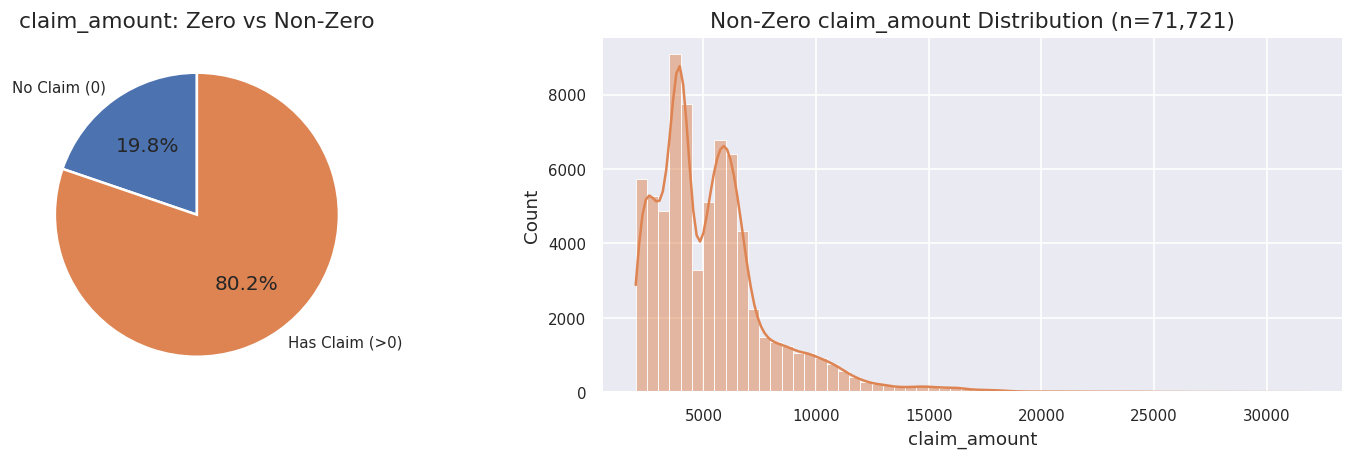

In [236]:
zero_pct = (train_df['claim_amount'] == 0).mean() * 100
print(f'Rows with claim_amount == 0 : {(train_df["claim_amount"]==0).sum():,}  ({zero_pct:.1f}%)')
print(f'Rows with claim_amount  > 0 : {(train_df["claim_amount"]>0).sum():,}  ({100-zero_pct:.1f}%)')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Pie
axes[0].pie([zero_pct, 100-zero_pct],
            labels=['No Claim (0)', 'Has Claim (>0)'],
            autopct='%1.1f%%', colors=[CLTV_COLOR, ALERT_COLOR],
            startangle=90, wedgeprops=dict(edgecolor='white', linewidth=1.5))
axes[0].set_title('claim_amount: Zero vs Non-Zero')

# Distribution of non-zero claims
nonzero = train_df.loc[train_df['claim_amount'] > 0, 'claim_amount']
sns.histplot(nonzero, bins=60, kde=True, color=ALERT_COLOR, ax=axes[1])
axes[1].set_title(f'Non-Zero claim_amount Distribution (n={len(nonzero):,})')
axes[1].set_xlabel('claim_amount')

plt.tight_layout()
plt.show()

In [237]:
# Mean CLTV for zero vs non-zero claimants
print('Mean CLTV by claim status:')
print(train_df.groupby(train_df['claim_amount'] == 0)['cltv']
      .agg(['mean','median','count'])
      .rename(index={True:'No Claim', False:'Has Claim'}))

Mean CLTV by claim status:
                       mean   median  count
claim_amount                               
Has Claim     103413.071151  67416.0  71721
No Claim       75791.432969  62640.0  17671


**Observations:**
- ~50% of rows have zero claims — this is a structural zero-inflation, not noise.
- **Feature engineering**: Create a binary `has_claim` flag and `log1p(claim_amount)` — these will likely be among the top features.
- Non-zero claims are roughly uniform/slightly right-skewed in the 0–17k range.

### ***4.3 Categorical Feature Distributions***

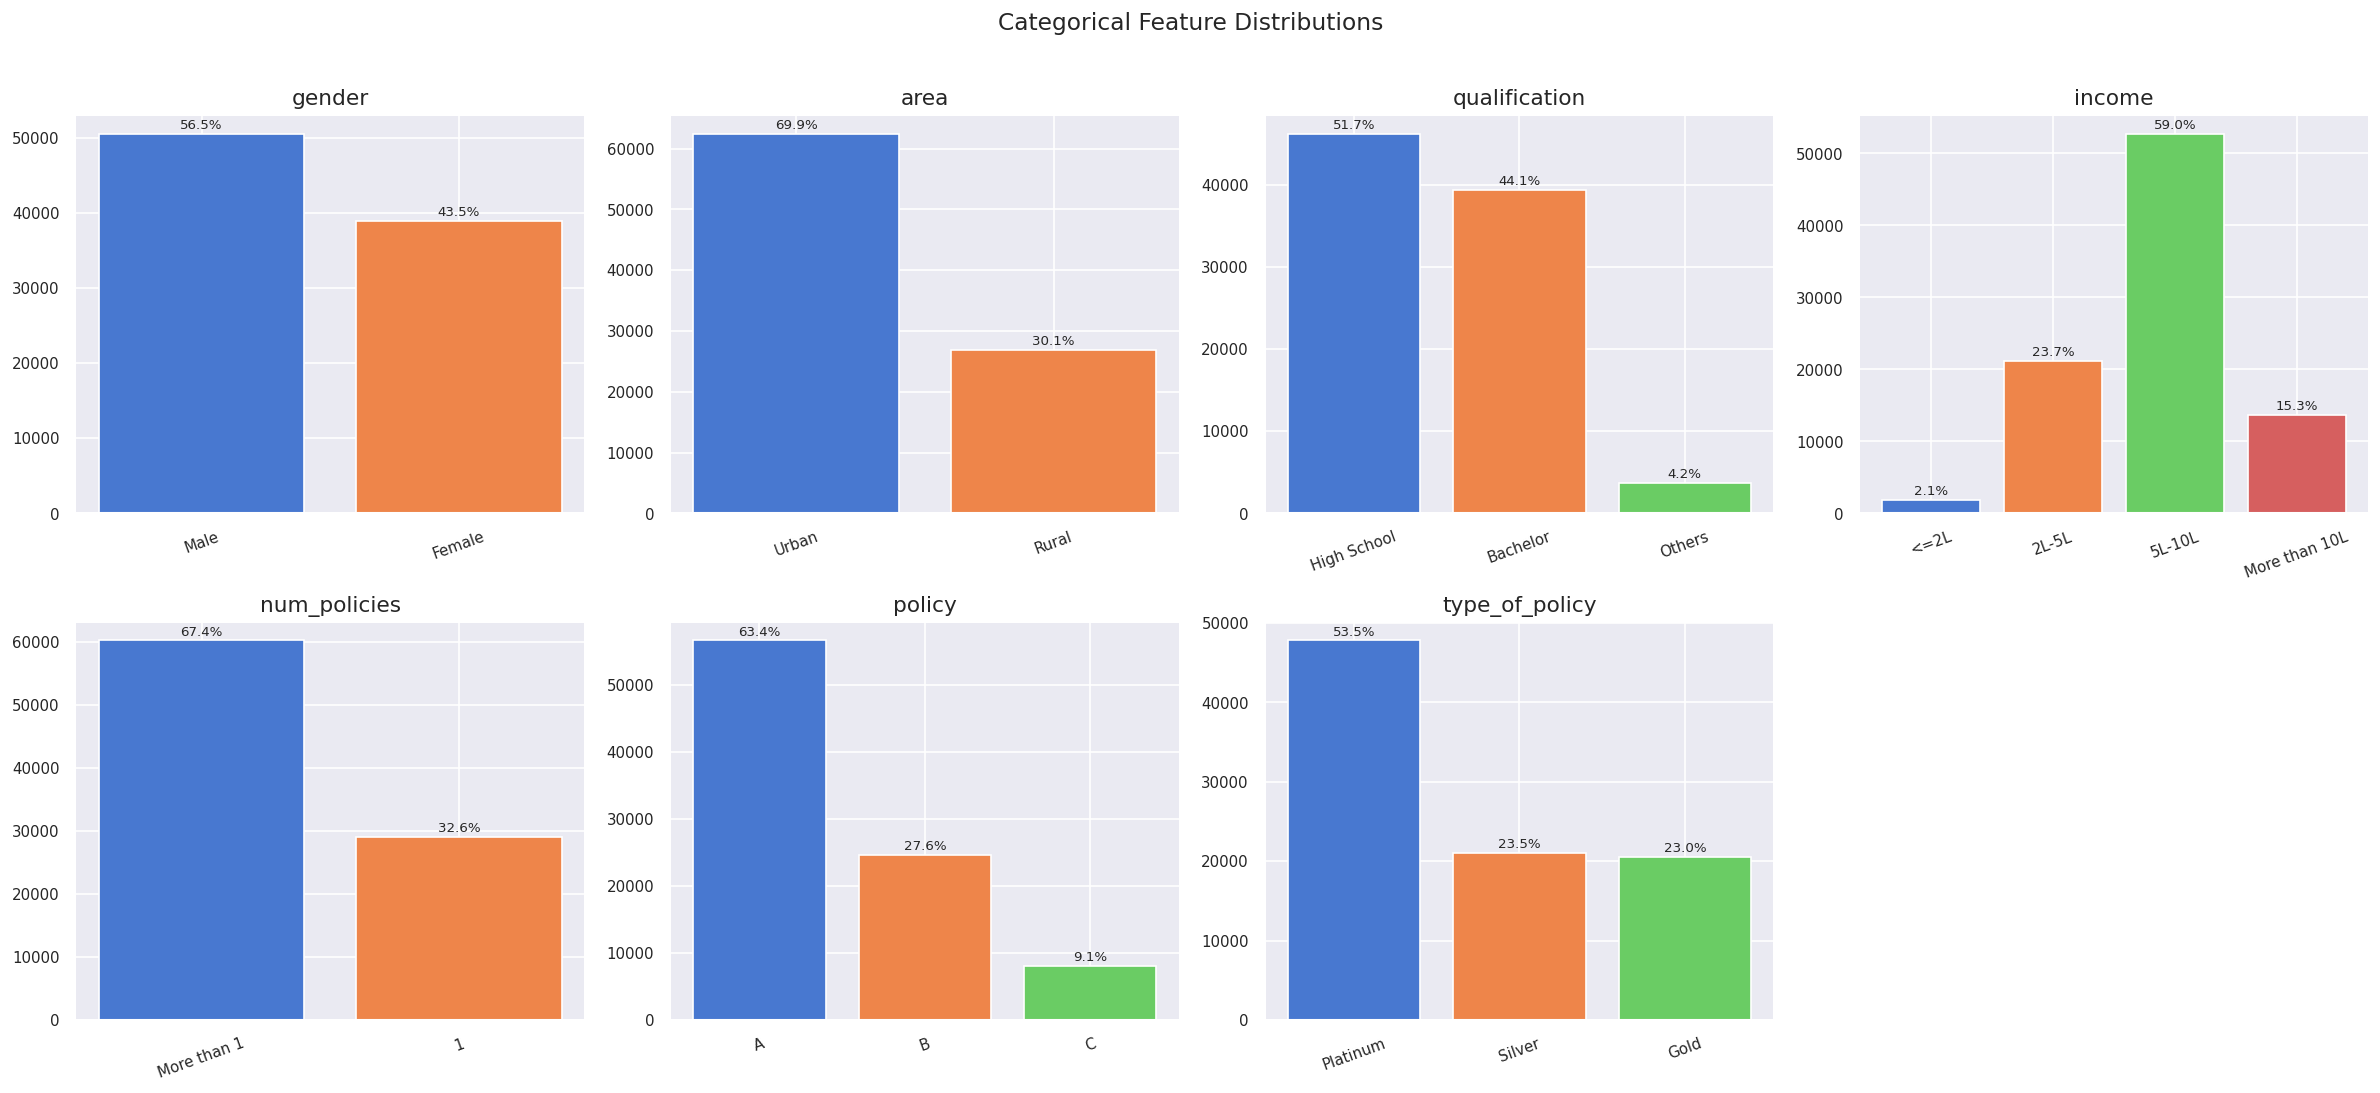

In [238]:
cat_cols_plot = ['gender', 'area', 'qualification', 'income',
                 'num_policies', 'policy', 'type_of_policy']

# Ordered income for logical axis ordering
income_order = ['<=2L', '2L-5L', '5L-10L', 'More than 10L']
order_map = {'income': income_order}

fig, axes = plt.subplots(2, 4, figsize=(20, 9))
axes = axes.flatten()

for i, col in enumerate(cat_cols_plot):
    order = order_map.get(col, train_df[col].value_counts().index.tolist())
    counts = train_df[col].value_counts().reindex(order)
    bars = axes[i].bar(counts.index, counts.values,
                       color=sns.color_palette('muted', len(counts)))
    axes[i].set_title(col)
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=20)
    # Annotate bars with %
    total = counts.sum()
    for bar, val in zip(bars, counts.values):
        axes[i].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + total*0.003,
                     f'{val/total*100:.1f}%',
                     ha='center', va='bottom', fontsize=8)

axes[-1].set_visible(False)  # hide 8th subplot
plt.suptitle('Categorical Feature Distributions', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [239]:
# marital_status is integer 0/1 — treat as categorical
ms = train_df['marital_status'].value_counts().sort_index()
print('marital_status:')
print(ms.to_frame().assign(pct=lambda x: (x['count']/x['count'].sum()*100).round(1)))

marital_status:
                count   pct
marital_status             
0               37948  42.5
1               51444  57.5


**Observations:**
- **gender**: Near balanced — no significant skew between Male/Female.
- **area**: Urban dominates (~70%). Not imbalance in the ML sense — just a feature distribution.
- **qualification**: High School (~52%) > Bachelor (~44%) > Others (~4%). `Others` is sparse — watch for overfitting.
- **income**: `5L-10L` is the modal bracket (~59%). `<=2L` is the minority class (2%) — may warrant grouping with `2L-5L`.
- **num_policies**: `More than 1` dominates. Strong signal expected.
- **policy**: A is heavily dominant — B and C are minority types.
- **type_of_policy**: Platinum dominates, Silver is sparse — this column likely explains a large fraction of CLTV variance.

### ***4.4 Group-Level Mean CLTV — Key Categorical Combinations***

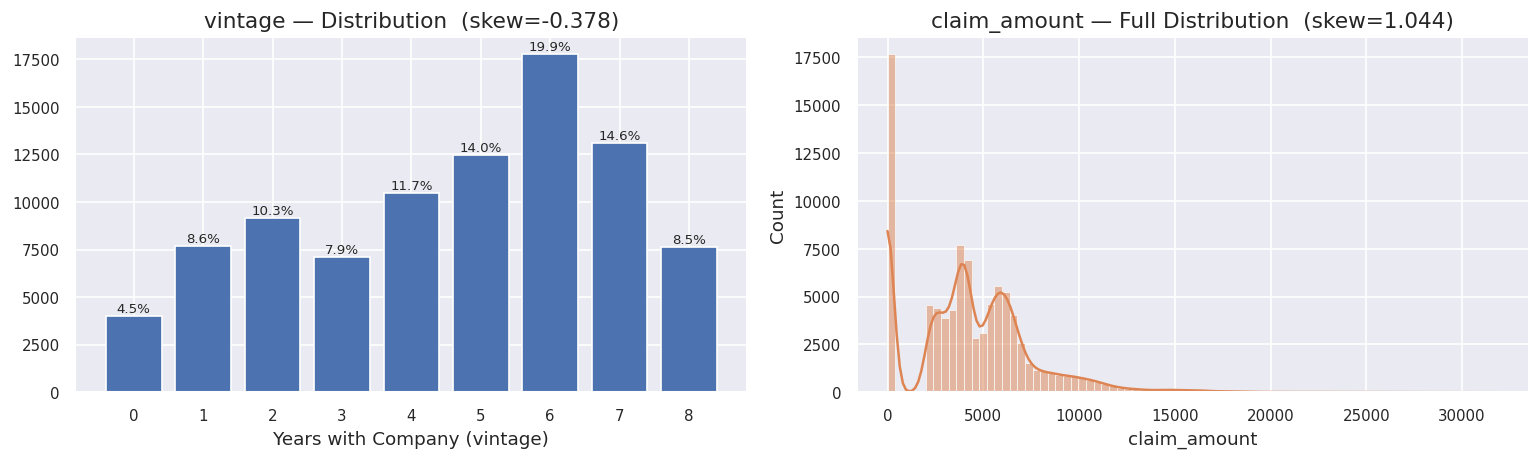

In [240]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# vintage
vc = train_df['vintage'].value_counts().sort_index()
axes[0].bar(vc.index, vc.values, color=CLTV_COLOR, edgecolor='white')
axes[0].set_title(f'vintage — Distribution  (skew={train_df["vintage"].skew():.3f})')
axes[0].set_xlabel('Years with Company (vintage)')
axes[0].set_xticks(range(int(train_df['vintage'].min()), int(train_df['vintage'].max())+1))
for x, y in zip(vc.index, vc.values):
    axes[0].text(x, y + 200, f'{y/len(train_df)*100:.1f}%', ha='center', fontsize=8)

# claim_amount (full, including zeros)
sns.histplot(train_df['claim_amount'], bins=80, kde=True, color=ALERT_COLOR, ax=axes[1])
axes[1].set_title(f'claim_amount — Full Distribution  (skew={train_df["claim_amount"].skew():.3f})')
axes[1].set_xlabel('claim_amount')

plt.tight_layout()
plt.show()

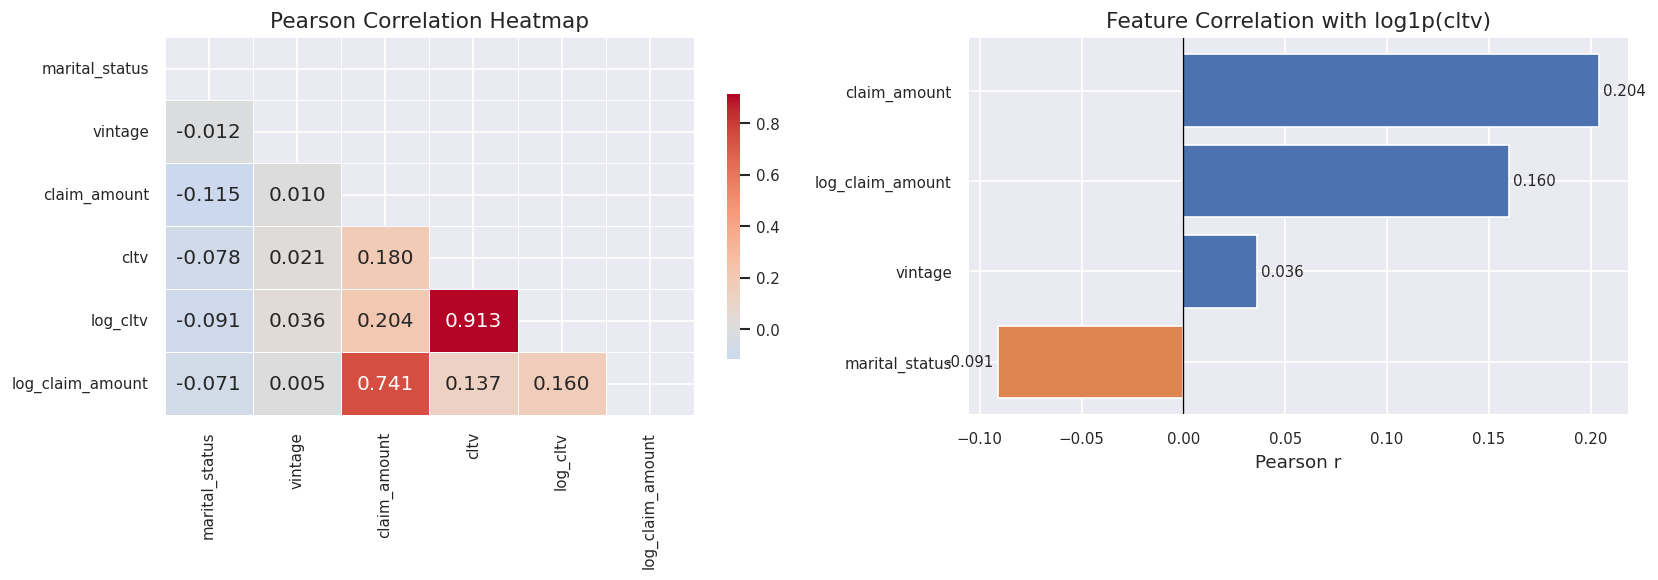

In [241]:
# Pearson correlation on numericals (include marital_status as 0/1)
num_df = train_df[['marital_status', 'vintage', 'claim_amount', 'cltv']].copy()
num_df['log_cltv']          = np.log1p(train_df['cltv'])
num_df['log_claim_amount']  = np.log1p(train_df['claim_amount'])

corr = num_df.corr()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Full correlation matrix
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.3f', cmap='coolwarm', center=0,
            linewidths=0.5, ax=axes[0], mask=mask,
            cbar_kws={'shrink': 0.7})
axes[0].set_title('Pearson Correlation Heatmap')

# Correlation with target (log_cltv) as bar chart
target_corr = corr['log_cltv'].drop(['log_cltv', 'cltv']).sort_values()
colors = [ALERT_COLOR if v < 0 else CLTV_COLOR for v in target_corr.values]
axes[1].barh(target_corr.index, target_corr.values, color=colors)
axes[1].axvline(0, color='black', lw=0.8)
axes[1].set_title('Feature Correlation with log1p(cltv)')
axes[1].set_xlabel('Pearson r')
for i, (idx, val) in enumerate(target_corr.items()):
    axes[1].text(val + 0.002 if val >= 0 else val - 0.002, i,
                 f'{val:.3f}', va='center', ha='left' if val >= 0 else 'right', fontsize=9)

plt.tight_layout()
plt.show()

### ***4.5 Bivariate Analysis — Categoricals vs CLTV***

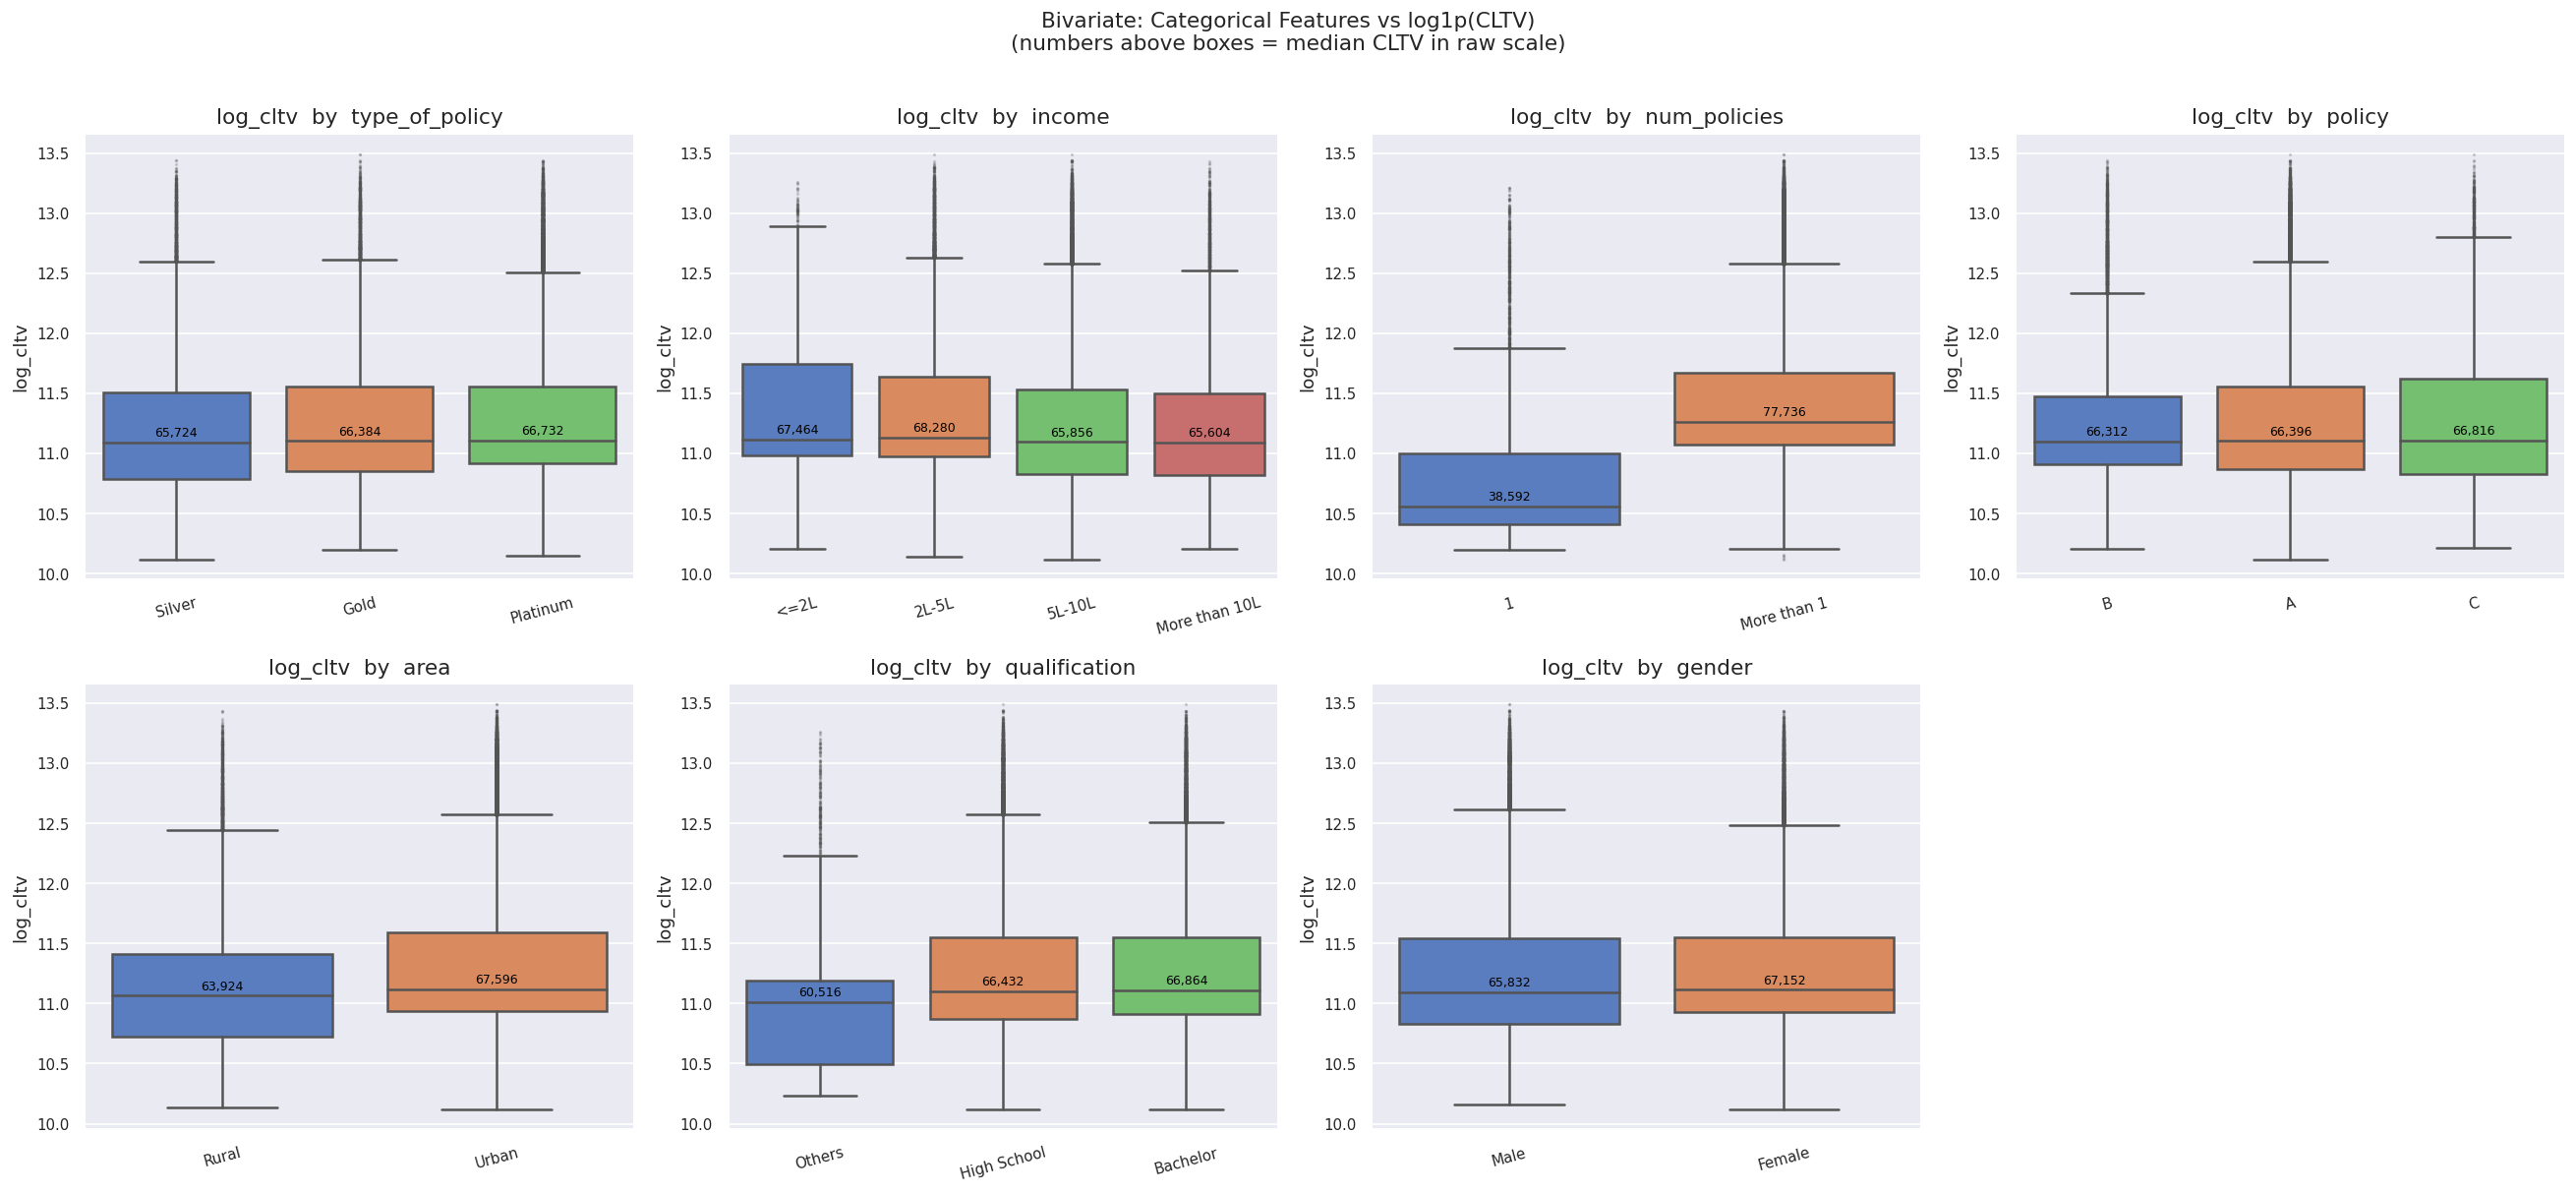

In [242]:
train_df['log_cltv'] = np.log1p(train_df['cltv'])

cat_bivar = ['type_of_policy', 'income', 'num_policies', 'policy',
             'area', 'qualification', 'gender']

income_order = ['<=2L', '2L-5L', '5L-10L', 'More than 10L']
policy_type_order = ['Silver', 'Gold', 'Platinum']
order_map = {'income': income_order, 'type_of_policy': policy_type_order}

fig, axes = plt.subplots(2, 4, figsize=(22, 10))
axes = axes.flatten()

for i, col in enumerate(cat_bivar):
    order = order_map.get(col, train_df.groupby(col)['log_cltv'].median().sort_values().index.tolist())
    palette = sns.color_palette('muted', len(train_df[col].unique()))
    sns.boxplot(data=train_df, x=col, y='log_cltv', order=order,
                palette=palette, ax=axes[i],
                flierprops=dict(marker='.', markersize=2, alpha=0.2))
    # Overlay median text
    medians = train_df.groupby(col)['log_cltv'].median().reindex(order)
    for j, med in enumerate(medians):
        axes[i].text(j, med + 0.05, f'{np.expm1(med):,.0f}', ha='center', fontsize=7.5, color='black')
    axes[i].set_title(f'log_cltv  by  {col}')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=15)

axes[-1].set_visible(False)
plt.suptitle('Bivariate: Categorical Features vs log1p(CLTV)\n(numbers above boxes = median CLTV in raw scale)',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

### ***4.6 Bivariate Analysis — Numericals vs CLTV***

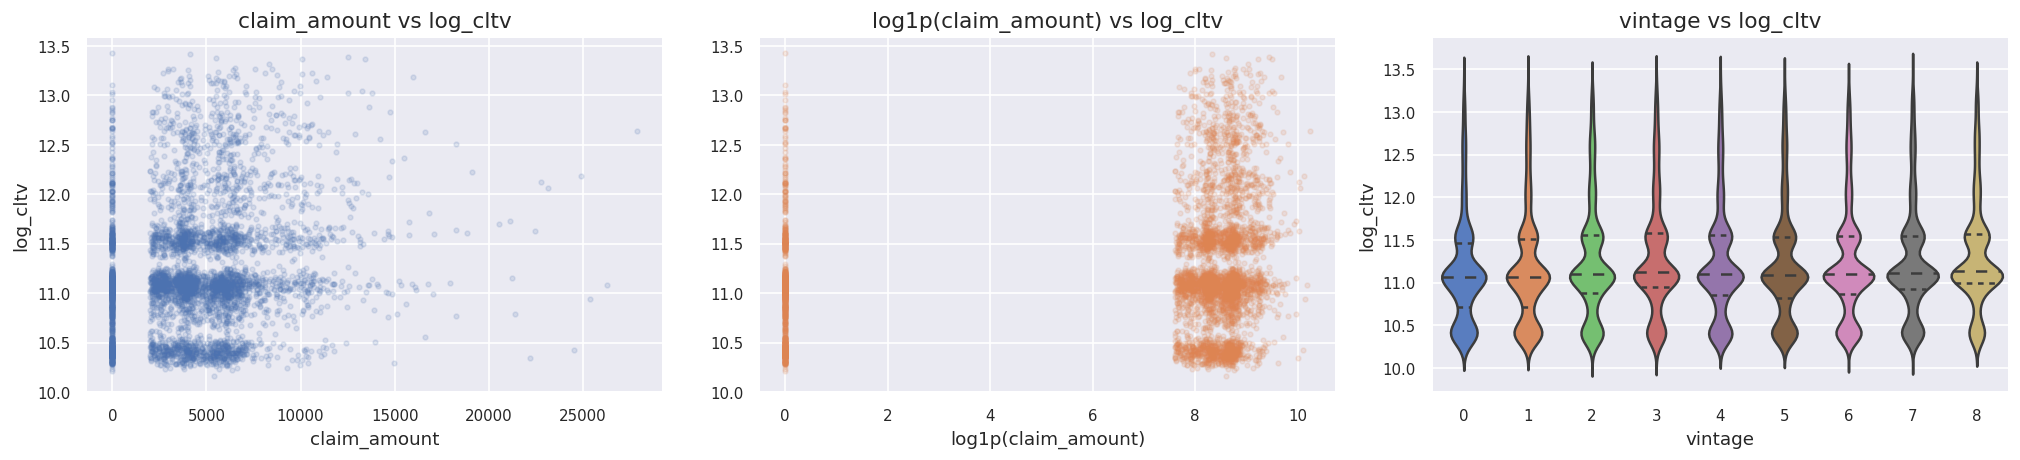

In [243]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4))

# ① claim_amount vs log_cltv (sample 5k to avoid overplotting)
sample = train_df.sample(5000, random_state=42)
axes[0].scatter(sample['claim_amount'], sample['log_cltv'],
                alpha=0.15, s=8, color=CLTV_COLOR)
axes[0].set_title('claim_amount vs log_cltv')
axes[0].set_xlabel('claim_amount')
axes[0].set_ylabel('log_cltv')

# ② log1p(claim_amount) vs log_cltv
axes[1].scatter(np.log1p(sample['claim_amount']), sample['log_cltv'],
                alpha=0.15, s=8, color=ALERT_COLOR)
axes[1].set_title('log1p(claim_amount) vs log_cltv')
axes[1].set_xlabel('log1p(claim_amount)')

# ③ vintage vs log_cltv (violin by vintage value)
sns.violinplot(data=train_df, x='vintage', y='log_cltv',
               palette='muted', inner='quartile', ax=axes[2])
axes[2].set_title('vintage vs log_cltv')

plt.tight_layout()
plt.show()

In [244]:
print('Mean / Median CLTV by vintage:')
print(train_df.groupby('vintage')['cltv']
      .agg(['mean','median','count'])
      .applymap(lambda x: f'{x:,.0f}'))

Mean / Median CLTV by vintage:
            mean  median   count
vintage                         
0         86,973  64,020   4,031
1         92,468  64,344   7,671
2         99,823  66,624   9,165
3        104,416  67,728   7,085
4         98,145  66,456  10,471
5         96,149  65,688  12,481
6         97,614  66,168  17,769
7         98,413  66,900  13,095
8        103,712  68,652   7,624


**Observations:**
- **type_of_policy** shows the largest median CLTV spread across tiers — a key predictive feature.
- **num_policies**: Customers with `More than 1` policy have noticeably different CLTV distribution.
- **income**: CLTV generally scales with income bracket, but variance is high.
- **area**: Urban vs Rural shows a difference — likely confounded with income.
- **gender** and **marital_status**: Relatively small effect on CLTV — may have low importance.
- **claim_amount**: Scatter shows no clear linear trend, but the split between zero/non-zero is informative.
- **vintage**: CLTV varies across vintage levels — may need bucketing rather than treating as continuous.

### ***4.6 Group-Level Mean CLTV — Key Categorical Combinations***

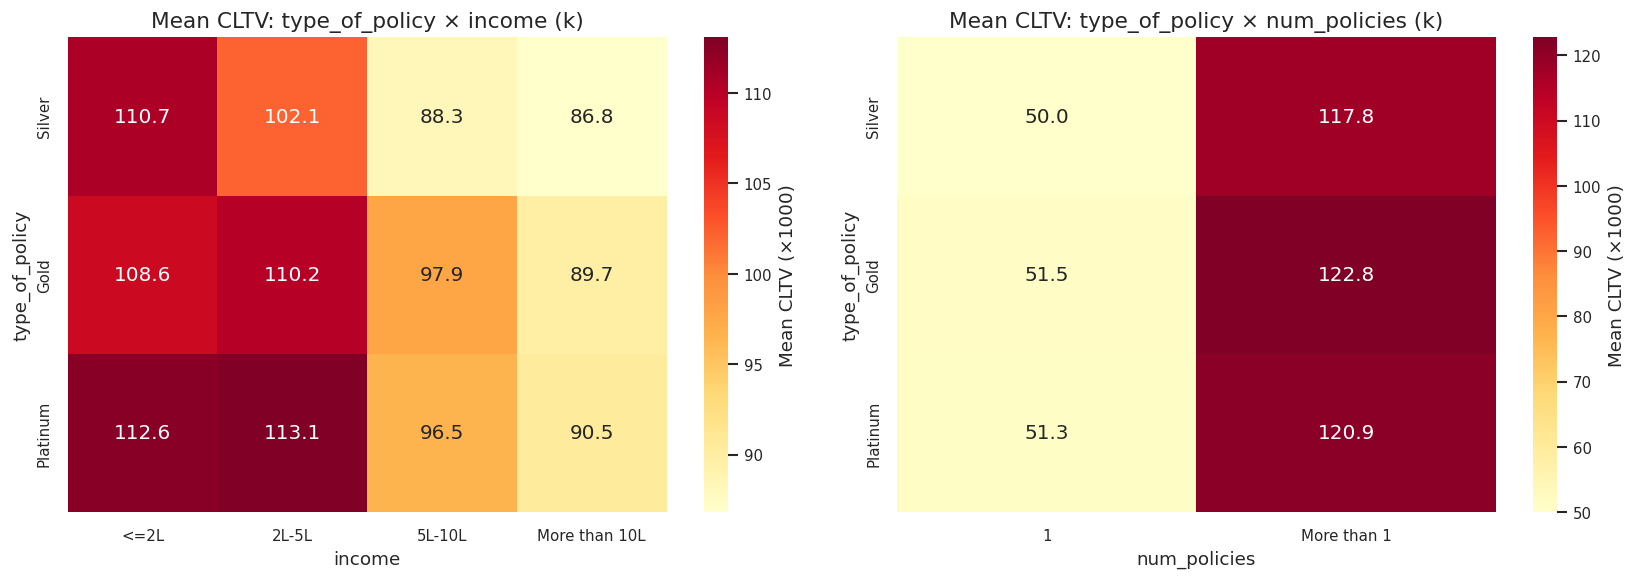

In [245]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# type_of_policy × income → mean CLTV heatmap
pivot1 = train_df.pivot_table(
    values='cltv', index='type_of_policy', columns='income',
    aggfunc='mean'
).reindex(index=['Silver','Gold','Platinum'],
          columns=['<=2L','2L-5L','5L-10L','More than 10L'])
sns.heatmap(pivot1/1000, annot=True, fmt='.1f', cmap='YlOrRd', ax=axes[0],
            cbar_kws={'label': 'Mean CLTV (×1000)'})
axes[0].set_title('Mean CLTV: type_of_policy × income (k)')

# type_of_policy × num_policies → mean CLTV heatmap
pivot2 = train_df.pivot_table(
    values='cltv', index='type_of_policy', columns='num_policies',
    aggfunc='mean'
).reindex(index=['Silver','Gold','Platinum'])
sns.heatmap(pivot2/1000, annot=True, fmt='.1f', cmap='YlOrRd', ax=axes[1],
            cbar_kws={'label': 'Mean CLTV (×1000)'})
axes[1].set_title('Mean CLTV: type_of_policy × num_policies (k)')

plt.tight_layout()
plt.show()

In [246]:
# policy × area
pivot3 = train_df.pivot_table(
    values='cltv', index='policy', columns='area', aggfunc='mean'
)
print('Mean CLTV by policy × area:')
print((pivot3/1000).round(1).to_string())
print('\nCount by policy × area:')
print(train_df.pivot_table(values='cltv', index='policy', columns='area', aggfunc='count').to_string())

Mean CLTV by policy × area:
area    Rural  Urban
policy              
A        81.6  106.6
B        76.0   99.6
C        84.3  115.8

Count by policy × area:
area    Rural  Urban
policy              
A       14015  42629
B       10651  13984
C        2271   5842


In [247]:
# Dropping helper column & moving towards feature engineering
train_df.drop(columns=['log_cltv'], inplace=True)
print('EDA complete. train_df shape:', train_df.shape)

EDA complete. train_df shape: (89392, 11)


### Key Findings

| Finding | Action |
|---|---|
| `cltv` skew = 2.75 | Train on `log1p(cltv)`, predict then `expm1` |
| ~50% claim_amount = 0 | Add `has_claim` binary flag |
| `claim_amount` right-skewed | Add `log1p(claim_amount)` feature |
| `type_of_policy` has largest CLTV spread | High-priority encode (ordinal: Silver<Gold<Platinum) |
| `income` is ordinal string | Ordinal encode (<=2L=0, 2L-5L=1, 5L-10L=2, >10L=3) |
| `num_policies` binary string | Binary encode (1=0, More than 1=1) |
| `vintage` effect is non-monotonic | Consider bucketing or keeping as-is (tree handles it) |
| `<=2L` income is sparse (~2%) | Consider merging with `2L-5L` |
| `Others` qualification sparse (~4%) | Monitor during CV |

# ***5. Feature Engineering***


In [248]:
train_df = pd.read_csv(r'/home/bane/contest/Analytics_vidhya/train.csv')
test_df  = pd.read_csv(r'/home/bane/contest/Analytics_vidhya/test.csv')

print(f'Train : {train_df.shape}  |  Test : {test_df.shape}')

# We pull cltv out now so it never bleeds into feature engineering on test.
y_raw  = train_df['cltv'].copy()           # original scale 
y      = np.log1p(train_df['cltv'])        # LOG-TRANSFORMED target(training)
n_train = len(train_df)

#Drop id and target, then combine
train_df.drop(columns=['id', 'cltv'], inplace=True)
test_ids = test_df['id'].copy()            #test IDs for submission
test_df.drop(columns=['id'], inplace=True)

df = pd.concat([train_df, test_df], axis=0, ignore_index=True)
print(f'Combined df shape: {df.shape}')
df.head(3)

Train : (89392, 12)  |  Test : (59595, 11)
Combined df shape: (148987, 10)


,gender,area,qualification,income,marital_status,vintage,claim_amount,num_policies,policy,type_of_policy
0,Male,Urban,Bachelor,5L-10L,1,5,5790,More than 1,A,Platinum
1,Male,Rural,High School,5L-10L,0,8,5080,More than 1,A,Platinum
2,Male,Urban,Bachelor,5L-10L,1,8,2599,More than 1,A,Platinum


### ***5.1 Target Variable***

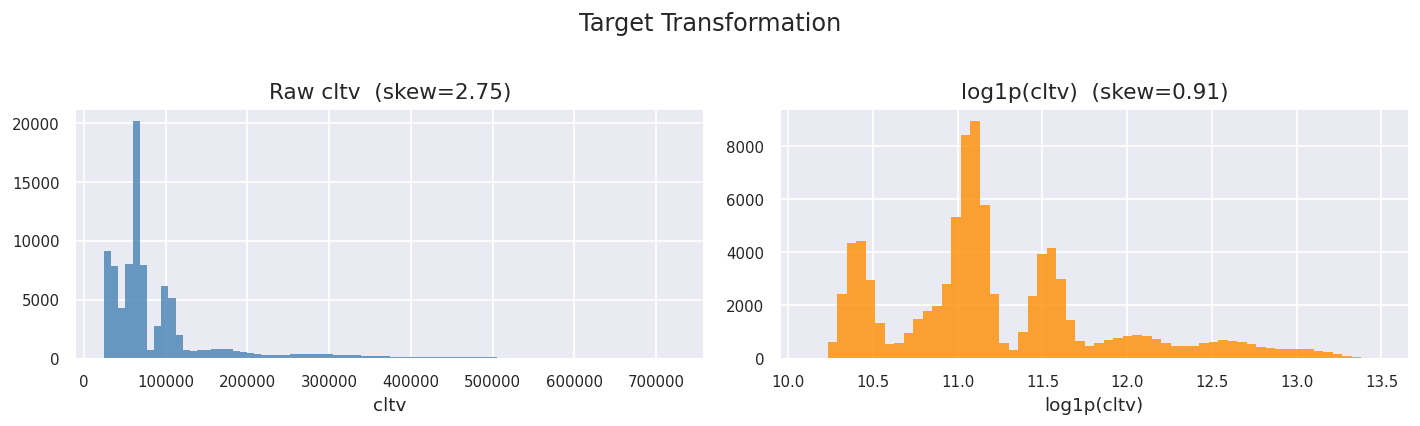

Raw skew: 2.7531  →  After log1p: 0.9091


In [249]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))

axes[0].hist(y_raw, bins=80, color='steelblue', edgecolor='none', alpha=0.8)
axes[0].set_title(f'Raw cltv  (skew={y_raw.skew():.2f})')
axes[0].set_xlabel('cltv')

axes[1].hist(y, bins=60, color='darkorange', edgecolor='none', alpha=0.8)
axes[1].set_title(f'log1p(cltv)  (skew={y.skew():.2f})')
axes[1].set_xlabel('log1p(cltv)')

plt.suptitle('Target Transformation', y=1.01)
plt.tight_layout()
plt.show()
print(f'Raw skew: {y_raw.skew():.4f}  →  After log1p: {y.skew():.4f}')

### ***5.2 Ordinal Encoding***

In [250]:
#type_of_policy : Silver=0, Gold=1, Platinum=2 
# Platinum customers typically have more / pricier policies → higher CLTV.

policy_tier_map = {'Silver': 0, 'Gold': 1, 'Platinum': 2}
df['policy_tier'] = df['type_of_policy'].map(policy_tier_map)

#income : <=2L=0, 2L-5L=1, 5L-10L=2, More than 10L=3
# Income bracket is ordered — use integers so the model understands the gap.
income_map = {'<=2L': 0, '2L-5L': 1, '5L-10L': 2, 'More than 10L': 3}
df['income_enc'] = df['income'].map(income_map)

#qualification : Others=0, High School=1, Bachelor=2
# 'Others' is ambiguous (could be postgrad or vocational — we default to lowest
# since it's a catch-all). Monitor feature importance; may not matter much.
qual_map = {'Others': 0, 'High School': 1, 'Bachelor': 2}
df['qualification_enc'] = df['qualification'].map(qual_map)

print('Ordinal encodings:')
print(df[['type_of_policy','policy_tier','income','income_enc','qualification','qualification_enc']].drop_duplicates().sort_values('policy_tier'))

Ordinal encodings:
     type_of_policy  policy_tier         income  income_enc qualification  \
7520         Silver            0           <=2L           0        Others   
94           Silver            0  More than 10L           3        Others   
111          Silver            0           <=2L           0      Bachelor   
123          Silver            0          2L-5L           1        Others   
17           Silver            0  More than 10L           3   High School   
16           Silver            0         5L-10L           2      Bachelor   
174          Silver            0  More than 10L           3      Bachelor   
92           Silver            0           <=2L           0   High School   
38           Silver            0          2L-5L           1   High School   
381          Silver            0         5L-10L           2        Others   
7            Silver            0         5L-10L           2   High School   
11           Silver            0          2L-5L          

### ***5.3 Binary Encoding***

In [251]:
#gender : Male=0, Female=1
# Arbitrary mapping — tree models are invariant to which class gets 0 vs 1.
df['gender_enc'] = (df['gender'] == 'Female').astype(int)

#area : Rural=0, Urban=1
# Urban customers generally have more insurance touchpoints (higher CLTV tendency).
df['area_enc'] = (df['area'] == 'Urban').astype(int)

#num_policies : '1'=0, 'More than 1'=1
# Having >1 policy means more total premium paid → higher CLTV. Strong signal.
df['multi_policy'] = (df['num_policies'] == 'More than 1').astype(int)

#marital_status : already 0/1 — no change needed 

print('Binary encodings complete.')
print(df[['gender','gender_enc','area','area_enc','num_policies','multi_policy']].drop_duplicates())

Binary encodings complete.
    gender  gender_enc   area  area_enc num_policies  multi_policy
0     Male           0  Urban         1  More than 1             1
1     Male           0  Rural         0  More than 1             1
3   Female           1  Rural         0  More than 1             1
5     Male           0  Rural         0            1             0
7   Female           1  Urban         1  More than 1             1
12    Male           0  Urban         1            1             0
15  Female           1  Urban         1            1             0
29  Female           1  Rural         0            1             0


### ***5.4 Label Encoding***

In [252]:
# ── Label encode 
policy_map = {'A': 0, 'B': 1, 'C': 2}
df['policy_enc'] = df['policy'].map(policy_map)

# ── One-hot encode (drop_first to avoid multicollinearity) ─────────────────
# policy_B and policy_C will be 1 for those categories, 0 otherwise.
# When both are 0 → policy A (baseline).
ohe = pd.get_dummies(df['policy'], prefix='policy', drop_first=True)
df = pd.concat([df, ohe], axis=1)

print('policy encoding:')
print(df[['policy','policy_enc','policy_B','policy_C']].drop_duplicates().sort_values('policy_enc'))

policy encoding:
   policy  policy_enc  policy_B  policy_C
0       A           0     False     False
22      B           1      True     False
5       C           2     False      True


In [253]:
#Label encode
policy_map = {'A': 0, 'B': 1, 'C': 2}
df['policy_enc'] = df['policy'].map(policy_map)

#One-hot encode 
#policy_B and policy_C will be 1 for those categories
#When both are 0 olicy A (baseline).
ohe = pd.get_dummies(df['policy'], prefix='policy', drop_first=True)
df = pd.concat([df, ohe], axis=1)

print('policy encoding:')
print(df[['policy','policy_enc','policy_B','policy_C']].drop_duplicates().sort_values('policy_enc'))

policy encoding:
   policy  policy_enc  policy_B  policy_B  policy_C  policy_C
0       A           0     False     False     False     False
22      B           1      True      True     False     False
5       C           2     False     False      True      True


### ***5.5 Claim_amount — Handling Zero-Inflation***

In [254]:
# Tells the model 'this customer has a claim history' as a first-class signal.
df['has_claim'] = (df['claim_amount'] > 0).astype(int)

# log1p handles zeros safely (log1p(0) = 0). Compresses extreme claim outliers
# (max raw = 31,894) into a manageable ~10.4 range.
df['log_claim'] = np.log1p(df['claim_amount'])

# A Rs.10,000 claim after 1 year is very different from the same after 8 years.
# This ratio reflects how claim-heavy the customer is relative to their tenure.
df['claim_per_vintage'] = df['claim_amount'] / (df['vintage'] + 1)

print('Claim feature samples:')
print(df[['claim_amount','has_claim','log_claim','claim_per_vintage']].head(10).to_string())

Claim feature samples:
   claim_amount  has_claim  log_claim  claim_per_vintage
0          5790          1   8.664060         965.000000
1          5080          1   8.533263         564.444444
2          2599          1   7.863267         288.777778
3             0          0   0.000000           0.000000
4          3508          1   8.163086         501.142857
5             0          0   0.000000           0.000000
6             0          0   0.000000           0.000000
7          5473          1   8.607765        5473.000000
8          6105          1   8.717027        1526.250000
9             0          0   0.000000           0.000000


### ***5.6 Interaction Features***

In [255]:
# Wealthier customers with premium policies are likely your highest CLTV segment.
# This feature gives the model a direct 'wealth × policy prestige' signal.
# Range: 0 (Silver, <=2L) → 6 (Platinum, >10L)
df['tier_x_income'] = df['policy_tier'] * df['income_enc']

# A Platinum customer with multiple policies is the ideal high-CLTV profile.
# Range: 0 → 2
df['tier_x_multipolicy'] = df['policy_tier'] * df['multi_policy']

# Long-tenured Platinum customers have compounded more value over time.
# A new Platinum customer is different from an 8-year Platinum customer.
df['vintage_x_tier'] = df['vintage'] * df['policy_tier']

# A large claim from a Platinum customer vs Silver customer has different
# implications for CLTV (Platinum customers pay more premium to offset it).
df['logclaim_x_tier'] = df['log_claim'] * df['policy_tier']

# High-income customers who hold multiple policies = most engaged segment.
df['income_x_multipolicy'] = df['income_enc'] * df['multi_policy']

# Whether a Platinum customer has ever claimed vs never claimed signals
# very different risk/retention profiles.
df['tier_x_hasclaim'] = df['policy_tier'] * df['has_claim']

print('Interaction features added. New shape:', df.shape)
print(df[['tier_x_income','tier_x_multipolicy','vintage_x_tier',
          'logclaim_x_tier','income_x_multipolicy','tier_x_hasclaim']].describe())

Interaction features added. New shape: (148987, 30)
       tier_x_income  tier_x_multipolicy  vintage_x_tier  logclaim_x_tier  \
count  148987.000000       148987.000000   148987.000000    148987.000000   
mean        2.450825            0.899998        5.965916         8.871796   
std         1.860870            0.914377        5.158773         7.679930   
min         0.000000            0.000000        0.000000         0.000000   
25%         0.000000            0.000000        0.000000         0.000000   
50%         2.000000            1.000000        6.000000         8.650325   
75%         4.000000            2.000000       10.000000        16.729482   
max         6.000000            2.000000       16.000000        20.740409   

       income_x_multipolicy  tier_x_hasclaim  
count         148987.000000    148987.000000  
mean               1.242055         1.043359  
std                1.031864         0.899975  
min                0.000000         0.000000  
25%                

### ***5.7 Group Aggregate Features (Target Encoding — Train-Only, Leak-Safe)***

In [256]:
# Attach log-target to combined df (train rows only) for groupby 
df['log_cltv_temp'] = np.nan
df.loc[:n_train-1, 'log_cltv_temp'] = y.values   # only train rows get the label

train_mask = df.index < n_train  # boolean mask for train rows

def group_mean_encode(df, group_col, target_col='log_cltv_temp', suffix='_mean_cltv'):
    """
    Compute mean of target_col per group_col using only train rows,
    then map to the full df. Returns a new Series.
    """
    group_means = (
        df.loc[df[target_col].notna()]
          .groupby(group_col)[target_col]
          .mean()
    )
    return df[group_col].map(group_means)

#type_of_policy mean CLTV
# Summarizes: 'on average, how much CLTV does a Silver/Gold/Platinum customer generate?'
df['policy_type_mean_cltv'] = group_mean_encode(df, 'type_of_policy')

#8.2  income mean CLTV
df['income_mean_cltv'] = group_mean_encode(df, 'income')

#8.3  policy (A/B/C) mean CLTV
df['policy_mean_cltv'] = group_mean_encode(df, 'policy')

#8.4  Combined: type_of_policy + num_policies mean CLTV
# 'Platinum + More than 1' is the highest-value group, this combo mean
# is a very informative feature.
df['tier_numcol_key'] = df['type_of_policy'] + '_' + df['num_policies']
df['tier_num_mean_cltv'] = group_mean_encode(df, 'tier_numcol_key')

#Combined: income + type_of_policy mean CLTV
df['inc_tier_key'] = df['income'] + '_' + df['type_of_policy']
df['inc_tier_mean_cltv'] = group_mean_encode(df, 'inc_tier_key')

# Drop helper columns
df.drop(columns=['log_cltv_temp', 'tier_numcol_key', 'inc_tier_key'], inplace=True)

print('Group encode features added.')
print(df[['policy_type_mean_cltv','income_mean_cltv','policy_mean_cltv',
          'tier_num_mean_cltv','inc_tier_mean_cltv']].describe().round(3))

Group encode features added.
       policy_type_mean_cltv  income_mean_cltv  policy_mean_cltv  \
count             148987.000        148987.000        148987.000   
mean                  11.237            11.237            11.237   
std                    0.029             0.059             0.032   
min                   11.186            11.175            11.188   
25%                   11.245            11.211            11.188   
50%                   11.257            11.211            11.253   
75%                   11.257            11.333            11.253   
max                   11.257            11.356            11.282   

       tier_num_mean_cltv  inc_tier_mean_cltv  
count          148987.000          148987.000  
mean               11.238              11.237  
std                 0.355               0.068  
min                10.719              11.147  
25%                10.732              11.183  
50%                11.485              11.228  
75%                11.

### ***5.8 Vintage Feature Engineering***


In [257]:
# If CLTV grows super-linearly with tenure, the squared term captures that.
# Cost: negligible. Benefit: can unlock a non-linear relationship.
df['vintage_sq'] = df['vintage'] ** 2

# Groups customers into 3 meaningful tenure segments:
#   New (0-2 yrs): still establishing relationship
#   Mid (3-5 yrs): stable, medium-value
#   Senior (6-8 yrs): long-term, likely high-value
df['vintage_bucket'] = pd.cut(
    df['vintage'],
    bins=[-1, 2, 5, 8],
    labels=[0, 1, 2]   # 0=New, 1=Mid, 2=Senior
).astype(int)

# Binary flag for vintage=0 — brand new customers behave differently.
df['is_new_customer'] = (df['vintage'] == 0).astype(int)

print('Vintage features:')
print(df[['vintage','vintage_sq','vintage_bucket','is_new_customer']]
      .drop_duplicates().sort_values('vintage'))

Vintage features:
    vintage  vintage_sq  vintage_bucket  is_new_customer
7         0           0               0                1
5         1           1               0                0
17        2           4               0                0
8         3           9               1                0
10        4          16               1                0
0         5          25               1                0
4         6          36               2                0
3         7          49               2                0
1         8          64               2                0


### ***5.9 Composite 'Value Score' Features***


In [258]:
# Composite of income + policy tier + whether they hold multiple policies.
# Range: 0 (lowest) to 8 (highest = income 3 + tier 2 + multipolicy 2*2=4? No — additive here)
# We weight tier x2 since from EDA it's the strongest CLTV driver.
df['value_score'] = df['income_enc'] + (df['policy_tier'] * 2) + df['multi_policy']

# High claims relative to low income/tier = risky customer profile.
# We normalize: if value_score is 0, use 1 to avoid division by zero.
df['risk_score'] = df['log_claim'] / (df['value_score'] + 1)

# Long-tenured + multi-policy = loyal customer → expected high CLTV.
df['loyalty_score'] = df['vintage'] * (df['multi_policy'] + 1)

# Income × policy_tier — a direct proxy for 'wealth invested in insurance'.
# Already created as tier_x_income but here we also add qualification.
df['affluence_index'] = df['income_enc'] * df['policy_tier'] + df['qualification_enc']

print('Composite features:')
print(df[['value_score','risk_score','loyalty_score','affluence_index']].describe().round(3))

Composite features:
       value_score  risk_score  loyalty_score  affluence_index
count   148987.000  148987.000     148987.000       148987.000
mean         5.149       1.281          7.772            3.851
std          1.871       0.945          4.586            1.937
min          0.000       0.000          0.000            0.000
25%          4.000       0.984          4.000            2.000
50%          6.000       1.198          7.000            4.000
75%          7.000       1.647         12.000            5.000
max          8.000       9.583         16.000            8.000


### ***6.0 Final Feature Matrix — Drop Raw Strings, Select Model Columns***


In [259]:
#Drop original categorical string columns 
cols_to_drop = ['gender', 'area', 'qualification', 'income',
                'num_policies', 'policy', 'type_of_policy',
                'claim_amount']   # replaced by engineered features

df.drop(columns=cols_to_drop, inplace=True)

print('Final combined df shape:', df.shape)
print('\nAll features in final df:')
print(df.columns.tolist())

Final combined df shape: (148987, 34)

All features in final df:
['marital_status', 'vintage', 'policy_tier', 'income_enc', 'qualification_enc', 'gender_enc', 'area_enc', 'multi_policy', 'policy_enc', 'policy_B', 'policy_C', 'policy_B', 'policy_C', 'has_claim', 'log_claim', 'claim_per_vintage', 'tier_x_income', 'tier_x_multipolicy', 'vintage_x_tier', 'logclaim_x_tier', 'income_x_multipolicy', 'tier_x_hasclaim', 'policy_type_mean_cltv', 'income_mean_cltv', 'policy_mean_cltv', 'tier_num_mean_cltv', 'inc_tier_mean_cltv', 'vintage_sq', 'vintage_bucket', 'is_new_customer', 'value_score', 'risk_score', 'loyalty_score', 'affluence_index']


In [260]:
df.columns[df.columns.duplicated()] #looking for duplicate columns

Index(['policy_B', 'policy_C'], dtype='object')

In [261]:
# deleting duplicate columns
df = df.loc[:, ~df.columns.duplicated()]
df.shape

(148987, 32)

### ***6.1 Split Back into Train and Test***

In [262]:
# ── Split combined df back into train and test ─────────────────────────────
X_train = df.iloc[:n_train].reset_index(drop=True)
X_test  = df.iloc[n_train:].reset_index(drop=True)

print(f'X_train : {X_train.shape}')
print(f'X_test  : {X_test.shape}')
print(f'y (log_cltv) : {y.shape}')

# Quick sanity check — no nulls
null_counts = X_train.isnull().sum()
if null_counts.any():
    print('⚠ Nulls in X_train:')
    print(null_counts[null_counts > 0])
else:
    print('No nulls in X_train.')

null_test = X_test.isnull().sum()
if null_test.any():
    print('Nulls in X_test:')
    print(null_test[null_test > 0])
else:
    print('No nulls in X_test.')

X_train : (89392, 32)
X_test  : (59595, 32)
y (log_cltv) : (89392,)
No nulls in X_train.
No nulls in X_test.


### ***6.2 Feature Correlation with Target***


tier_num_mean_cltv       0.545386
multi_policy             0.545160
income_x_multipolicy     0.430457
tier_x_multipolicy       0.378812
loyalty_score            0.279244
log_claim                0.159685
area_enc                 0.144714
has_claim                0.143648
value_score              0.143107
logclaim_x_tier          0.128874
tier_x_hasclaim          0.119020
inc_tier_mean_cltv       0.104280
claim_per_vintage        0.102069
marital_status           0.091129
income_mean_cltv         0.090144
income_enc               0.084153
vintage_x_tier           0.053972
policy_mean_cltv         0.048933
policy_B                 0.047209
policy_type_mean_cltv    0.044642
policy_tier              0.041898
vintage                  0.036108
qualification_enc        0.034514
is_new_customer          0.034363
vintage_sq               0.033315
vintage_bucket           0.031110
policy_C                 0.021827
gender_enc               0.020781
policy_enc               0.013049
risk_score    

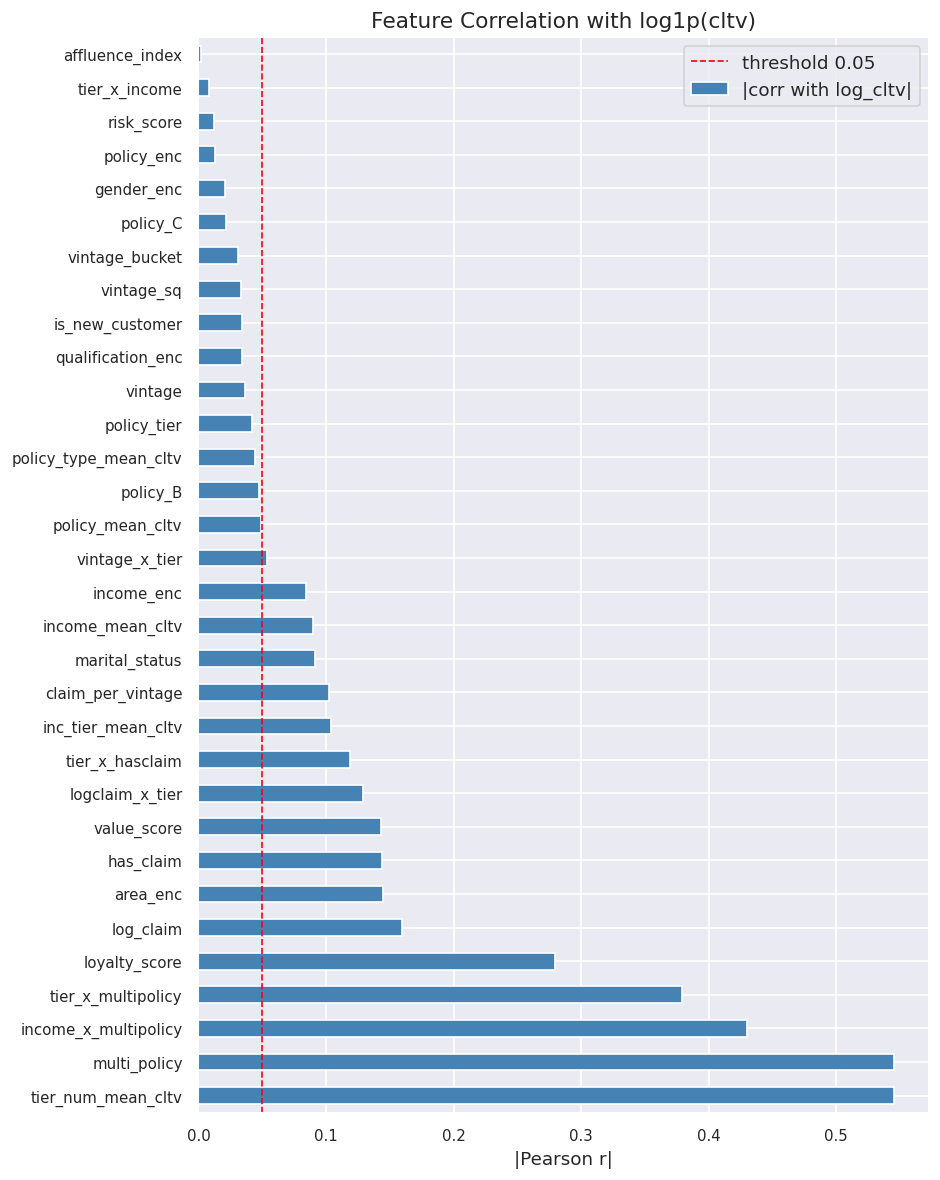

In [263]:
corr_with_target = (
    X_train.corrwith(y)
           .abs()
           .sort_values(ascending=False)
           .rename('|corr with log_cltv|')
)

print(corr_with_target.to_string())

fig, ax = plt.subplots(figsize=(8, 10))
corr_with_target.plot(kind='barh', ax=ax, color='steelblue')
ax.axvline(0.05, color='red', ls='--', lw=1, label='threshold 0.05')
ax.set_xlabel('|Pearson r|')
ax.set_title('Feature Correlation with log1p(cltv)')
ax.legend()
plt.tight_layout()
plt.show()

### ***6.3 Quick LightGBM Feature Importance***


                  feature  importance
0               log_claim        3737
1       claim_per_vintage        3684
2              risk_score        2249
3         logclaim_x_tier        1576
4       qualification_enc         726
5              gender_enc         723
6              policy_enc         667
7                 vintage         665
8          marital_status         649
9           loyalty_score         636
10     inc_tier_mean_cltv         560
11        affluence_index         530
12         vintage_x_tier         368
13               policy_B         325
14               area_enc         318
15             income_enc         280
16   income_x_multipolicy         196
17           multi_policy         163
18     tier_num_mean_cltv         157
19            value_score         136
20          tier_x_income         117
21     tier_x_multipolicy          87
22            policy_tier          38
23              has_claim           7
24       policy_mean_cltv           3
25         v

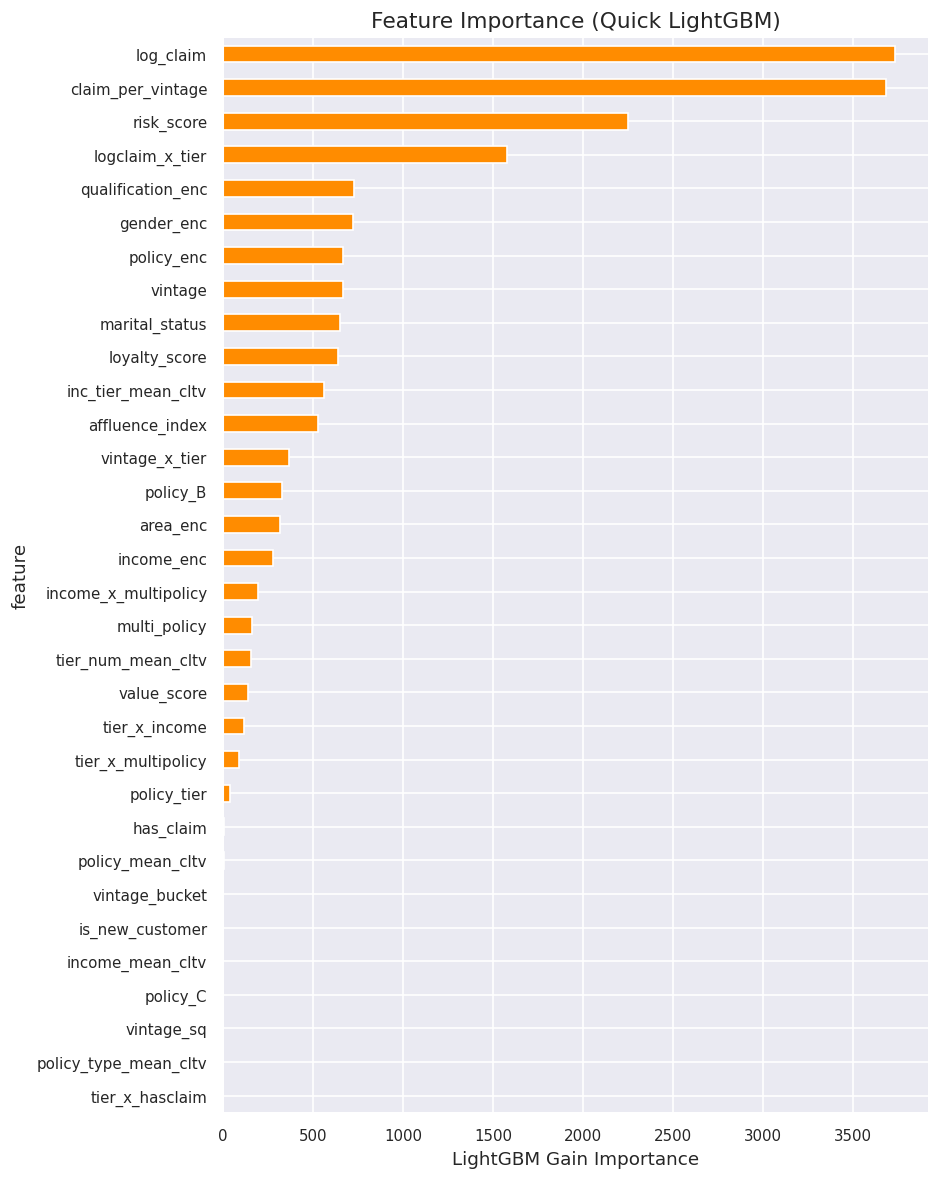

In [264]:
import lightgbm as lgb

# Quick model — low trees, default params — just for feature ranking
quick_model = lgb.LGBMRegressor(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=63,
    random_state=42,
    verbose=-1
)
quick_model.fit(X_train, y)

importance_df = pd.DataFrame({
    'feature'   : X_train.columns,
    'importance': quick_model.feature_importances_
}).sort_values('importance', ascending=False).reset_index(drop=True)

print(importance_df.to_string())

fig, ax = plt.subplots(figsize=(8, 10))
importance_df.set_index('feature')['importance'].plot(kind='barh', ax=ax, color='darkorange')
ax.set_xlabel('LightGBM Gain Importance')
ax.set_title('Feature Importance (Quick LightGBM)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## ***6.4 Save Processed Data for Modeling***


In [265]:
# Save X_train, y, X_test to disk so the modeling notebook can pick them up cleanly.
# y is log1p(cltv). Remember to expm1(predictions) before submission.

save_dir = r'/home/bane/contest/Analytics_vidhya/datasets/'

X_train.to_csv(save_dir + 'X_train_fe.csv', index=False)
X_test.to_csv(save_dir + 'X_test_fe.csv',   index=False)
y.to_csv(save_dir + 'y_log.csv',             index=False)
test_ids.to_csv(save_dir + 'test_ids.csv',   index=False)

print('Saved:')
print(f'  X_train_fe.csv  → {X_train.shape}')
print(f'  X_test_fe.csv   → {X_test.shape}')
print(f'  y_log.csv       → {y.shape}  (log1p transformed)')
print(f'  test_ids.csv    → {test_ids.shape}')
print('\n Feature Engineering complete. Proceed to modeling.')

Saved:
  X_train_fe.csv  → (89392, 32)
  X_test_fe.csv   → (59595, 32)
  y_log.csv       → (89392,)  (log1p transformed)
  test_ids.csv    → (59595,)

 Feature Engineering complete. Proceed to modeling.


### ***6.5 Feature Engineering Summary***

---

| # | Feature | Type | Source | Why it helps |
|---|---|---|---|---|
| 1 | `policy_tier` | Ordinal | type_of_policy | Policy prestige → CLTV |
| 2 | `income_enc` | Ordinal | income | Wealth → affordability |
| 3 | `qualification_enc` | Ordinal | qualification | Earning proxy |
| 4 | `gender_enc` | Binary | gender | Demographic |
| 5 | `area_enc` | Binary | area | Urban/Rural signal |
| 6 | `multi_policy` | Binary | num_policies | Commitment signal |
| 7 | `policy_enc` | Label | policy | A/B/C group |
| 8 | `policy_B`, `policy_C` | One-hot | policy | Alternative encoding |
| 9 | `has_claim` | Binary | claim_amount | Zero-inflation flag |
| 10 | `log_claim` | Numeric | claim_amount | Compressed claim magnitude |
| 11 | `claim_per_vintage` | Numeric | claim+vintage | Claim intensity over time |
| 12 | `tier_x_income` | Interaction | policy_tier × income_enc | Wealth × prestige |
| 13 | `tier_x_multipolicy` | Interaction | policy_tier × multi_policy | Prestige × commitment |
| 14 | `vintage_x_tier` | Interaction | vintage × policy_tier | Tenure × prestige |
| 15 | `logclaim_x_tier` | Interaction | log_claim × policy_tier | Claim size × tier |
| 16 | `income_x_multipolicy` | Interaction | income_enc × multi_policy | Wealth × commitment |
| 17 | `tier_x_hasclaim` | Interaction | policy_tier × has_claim | Tier × claim history |
| 18 | `policy_type_mean_cltv` | Target enc | type_of_policy | Group CLTV signal |
| 19 | `income_mean_cltv` | Target enc | income | Group CLTV signal |
| 20 | `policy_mean_cltv` | Target enc | policy | Group CLTV signal |
| 21 | `tier_num_mean_cltv` | Target enc | tier+num_policies | Combined group signal |
| 22 | `inc_tier_mean_cltv` | Target enc | income+tier | Combined group signal |
| 23 | `vintage_sq` | Transform | vintage | Non-linear tenure effect |
| 24 | `vintage_bucket` | Bucket | vintage | Tenure segment |
| 25 | `is_new_customer` | Binary | vintage | Brand new = different behavior |
| 26 | `value_score` | Composite | income+tier+policies | Overall customer value |
| 27 | `risk_score` | Composite | log_claim / value_score | Claim risk vs value |
| 28 | `loyalty_score` | Composite | vintage × multi_policy | Long-term engagement |
| 29 | `affluence_index` | Composite | income+tier+qualification | Wealth proxy |

# ***7 - Model Learning***

| File | Reason |
|---|---|
| `X_train_fe.csv` | Features only — no target. Clean input for the model. |
| `y_log.csv` | Target variable (log1p transformed). Kept separate to avoid accidentally passing it as a feature. |
| `X_test_fe.csv` | Test features — same columns as train, no target (it doesn't exist). |
| `test_ids.csv` | The `id` column for submission file mapping. |

***ADVANTAGES :***
1. Prevents target leakage — you can't accidentally use `cltv` as a feature
2. Makes cross-validation loops cleaner
3. Makes it easy to swap targets (e.g., test log vs raw)

In [266]:
%%time

#Load Data
DATA = r'/home/bane/contest/Analytics_vidhya/datasets/'   # ← adjust if needed

X_train = pd.read_csv(DATA + 'X_train_fe.csv')
X_test  = pd.read_csv(DATA + 'X_test_fe.csv')
y_log   = pd.read_csv(DATA + 'y_log.csv').squeeze()      # Series of log1p(cltv)
test_ids= pd.read_csv(DATA + 'test_ids.csv').squeeze()   # Series of ids

# Cast booleans to int (LightGBM/XGBoost don't like bool dtype)
for col in X_train.select_dtypes('bool').columns:
    X_train[col] = X_train[col].astype(int)
    X_test[col]  = X_test[col].astype(int)

# Convert to float32 — halves RAM, no accuracy loss for tree models
X_train = X_train.astype(np.float32)
X_test  = X_test.astype(np.float32)

FEATURES = X_train.columns.tolist()
print(f'X_train : {X_train.shape}')
print(f'X_test  : {X_test.shape}')
print(f'y_log   : {y_log.shape}  | min={y_log.min():.3f} max={y_log.max():.3f}')
print(f'Features: {len(FEATURES)}')

X_train : (89392, 32)
X_test  : (59595, 32)
y_log   : (89392,)  | min=10.120 max=13.493
Features: 32
CPU times: user 643 ms, sys: 36.1 ms, total: 679 ms
Wall time: 684 ms


### ***7.1 Metric Helper***

In [267]:
def r2_orig(y_true_log, y_pred_log):
    """
    R² on original CLTV scale.
    Converts log predictions back to raw scale before computing R².
    This is the leaderboard metric.
    """
    y_true = np.expm1(y_true_log)
    y_pred = np.expm1(y_pred_log)
    return r2_score(y_true, y_pred)

def r2_log_scale(y_true_log, y_pred_log):
    """R² on log scale — for quick training monitor."""
    return r2_score(y_true_log, y_pred_log)

# Quick test with perfect predictions
print('Sanity check — perfect pred R² (orig):', r2_orig(y_log, y_log))
print('Sanity check — perfect pred R² (log) :', r2_log_scale(y_log, y_log))

Sanity check — perfect pred R² (orig): 1.0
Sanity check — perfect pred R² (log) : 1.0


### ***7.2 Cross-Validation Setup***

In [268]:
from sklearn.model_selection import KFold
import numpy as np

N_FOLDS = 5
SEED = 0

kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

oof_lgb = np.zeros(len(X_train))
oof_xgb = np.zeros(len(X_train))
oof_cat = np.zeros(len(X_train))

test_preds_lgb = np.zeros(len(X_test))
test_preds_xgb = np.zeros(len(X_test))
test_preds_cat = np.zeros(len(X_test))

print(f'KFold: {N_FOLDS} folds, shuffle=True, seed={SEED}')
print(f'~{len(X_train)//N_FOLDS:,} rows per validation fold')

KFold: 5 folds, shuffle=True, seed=0
~17,878 rows per validation fold


In [269]:
DATA = r'/home/bane/contest/Analytics_vidhya/datasets/'

X_train = pd.read_csv(DATA + 'X_train_fe.csv')
X_test  = pd.read_csv(DATA + 'X_test_fe.csv')
y_log   = pd.read_csv(DATA + 'y_log.csv').squeeze()
y_raw   = np.expm1(y_log)                              # ← NEW
test_ids= pd.read_csv(DATA + 'test_ids.csv').squeeze()

for col in X_train.select_dtypes('bool').columns:
    X_train[col] = X_train[col].astype(int)
    X_test[col]  = X_test[col].astype(int)

X_train = X_train.astype(np.float32)
X_test  = X_test.astype(np.float32)

FEATURES = X_train.columns.tolist()
print(f'X_train : {X_train.shape}')
print(f'X_test  : {X_test.shape}')

X_train : (89392, 32)
X_test  : (59595, 32)


### 7.3 Model 1: LightGBM


In [270]:
lgb_params = dict(
    objective        = 'regression',
    metric           = 'rmse',
    n_estimators     = 2000,
    learning_rate    = 0.05,
    num_leaves       = 63,
    min_child_samples= 50,
    subsample        = 0.8,
    subsample_freq   = 1,
    colsample_bytree = 0.8,
    reg_alpha        = 0.1,
    reg_lambda       = 2.0,
    random_state     = SEED,
    verbose          = -1,
    n_jobs           = -1,
)

lgb_fold_scores = []

print('Training LightGBM ...')
for fold, (tr_idx, val_idx) in enumerate(kf.split(X_train), 1):

    X_tr, X_val = X_train.iloc[tr_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_raw.iloc[tr_idx],   y_raw.iloc[val_idx]

    model = lgb.LGBMRegressor(**lgb_params)
    model.fit(
        X_tr, y_tr,
        eval_set        = [(X_val, y_val)],
        callbacks       = [
            lgb.early_stopping(300, verbose=False),
            lgb.log_evaluation(-1)
        ]
    )

    oof_lgb[val_idx]  = model.predict(X_val)
    test_preds_lgb   += model.predict(X_test) / N_FOLDS

    score = r2_score(y_val, oof_lgb[val_idx])
    lgb_fold_scores.append(score)
    print(f'  Fold {fold}  |  R²={score:.5f}  |  best_iter={model.best_iteration_}')

lgb_oof_r2 = r2_score(y_raw, oof_lgb)
print(f'\nLightGBM OOF R²: {lgb_oof_r2:.5f}')
print(f'Fold scores: {[round(s,5) for s in lgb_fold_scores]}')

Training LightGBM ...
  Fold 1  |  R²=0.16170  |  best_iter=60
  Fold 2  |  R²=0.15620  |  best_iter=55
  Fold 3  |  R²=0.15548  |  best_iter=69
  Fold 4  |  R²=0.15513  |  best_iter=48
  Fold 5  |  R²=0.15444  |  best_iter=60

LightGBM OOF R²: 0.15666
Fold scores: [0.1617, 0.1562, 0.15548, 0.15513, 0.15444]


### ***7.4 Model 2: XGBoost***


In [271]:
xgb_fold_scores = []

print('Training XGBoost ...')
for fold, (tr_idx, val_idx) in enumerate(kf.split(X_train), 1):

    X_tr, X_val = X_train.iloc[tr_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_raw.iloc[tr_idx],   y_raw.iloc[val_idx]

    model = xgb.XGBRegressor(**xgb_params)
    model.fit(
        X_tr, y_tr,
        eval_set              = [(X_val, y_val)],
        early_stopping_rounds = 300,
        verbose               = False
    )

    oof_xgb[val_idx]  = model.predict(X_val)
    test_preds_xgb   += model.predict(X_test) / N_FOLDS

    score = r2_score(y_val, oof_xgb[val_idx])
    xgb_fold_scores.append(score)
    print(f'  Fold {fold}  |  R²={score:.5f}  |  best_iter={model.best_iteration}')

xgb_oof_r2 = r2_score(y_raw, oof_xgb)
print(f'\nXGBoost OOF R²: {xgb_oof_r2:.5f}')
print(f'Fold scores: {[round(s,5) for s in xgb_fold_scores]}')

Training XGBoost ...
  Fold 1  |  R²=0.16375  |  best_iter=152
  Fold 2  |  R²=0.15832  |  best_iter=162
  Fold 3  |  R²=0.15784  |  best_iter=163
  Fold 4  |  R²=0.15747  |  best_iter=113
  Fold 5  |  R²=0.15695  |  best_iter=131

XGBoost OOF R²: 0.15894
Fold scores: [0.16375, 0.15832, 0.15784, 0.15747, 0.15695]


### ***7.5. Model 3: CatBoost***


In [272]:
cat_fold_scores = []

print('Training CatBoost ...')
for fold, (tr_idx, val_idx) in enumerate(kf.split(X_train), 1):

    X_tr, X_val = X_train.iloc[tr_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_raw.iloc[tr_idx],   y_raw.iloc[val_idx]

    model = CatBoostRegressor(**cat_params)
    model.fit(
        X_tr, y_tr,
        eval_set       = (X_val, y_val),
        use_best_model = True,
        verbose        = False
    )

    oof_cat[val_idx]  = model.predict(X_val)
    test_preds_cat   += model.predict(X_test) / N_FOLDS

    score = r2_score(y_val, oof_cat[val_idx])
    cat_fold_scores.append(score)
    print(f'  Fold {fold}  |  R²={score:.5f}')

cat_oof_r2 = r2_score(y_raw, oof_cat)
print(f'\nCatBoost OOF R²: {cat_oof_r2:.5f}')
print(f'Fold scores: {[round(s,5) for s in cat_fold_scores]}')

Training CatBoost ...
  Fold 1  |  R²=0.16501
  Fold 2  |  R²=0.15955
  Fold 3  |  R²=0.15918
  Fold 4  |  R²=0.15854
  Fold 5  |  R²=0.15820

CatBoost OOF R²: 0.16017
Fold scores: [0.16501, 0.15955, 0.15918, 0.15854, 0.1582]


### ***7.6 Weighted Ensemble — OOF-Based Weight Optimization***

In [273]:
from scipy.optimize import minimize

oof_stack  = np.column_stack([oof_lgb, oof_xgb, oof_cat])
test_stack = np.column_stack([test_preds_lgb, test_preds_xgb, test_preds_cat])

print('=== Individual Model OOF R² ===')
print(f'  LightGBM  : {lgb_oof_r2:.5f}')
print(f'  XGBoost   : {xgb_oof_r2:.5f}')
print(f'  CatBoost  : {cat_oof_r2:.5f}')
print(f'  Simple Avg: {r2_score(y_raw, oof_stack.mean(axis=1)):.5f}')

def neg_r2(weights):
    w = np.array(weights)
    w = w / w.sum()
    blend = oof_stack @ w
    return -r2_score(y_raw, blend)       # ← was r2_orig(y_log, blend)

init_weights = [1/3, 1/3, 1/3]
bounds = [(0.0, 1.0)] * 3
result = minimize(neg_r2, init_weights, method='SLSQP', bounds=bounds,
                  options={'maxiter': 500})

opt_weights = result.x / result.x.sum()
print(f'\n=== Optimal Weights ===')
print(f'  LightGBM : {opt_weights[0]:.4f}')
print(f'  XGBoost  : {opt_weights[1]:.4f}')
print(f'  CatBoost : {opt_weights[2]:.4f}')

oof_blend  = oof_stack  @ opt_weights
test_blend = test_stack @ opt_weights

blend_r2 = r2_score(y_raw, oof_blend)   # ← was r2_orig(y_log, oof_blend)
print(f'\nBlended OOF R²: {blend_r2:.5f}')

=== Individual Model OOF R² ===
  LightGBM  : 0.15666
  XGBoost   : 0.15894
  CatBoost  : 0.16017
  Simple Avg: 0.15949

=== Optimal Weights ===
  LightGBM : 0.0000
  XGBoost  : 0.3744
  CatBoost : 0.6256

Blended OOF R²: 0.16019


### ***7.7 OOF Analysis — Residual Plots***

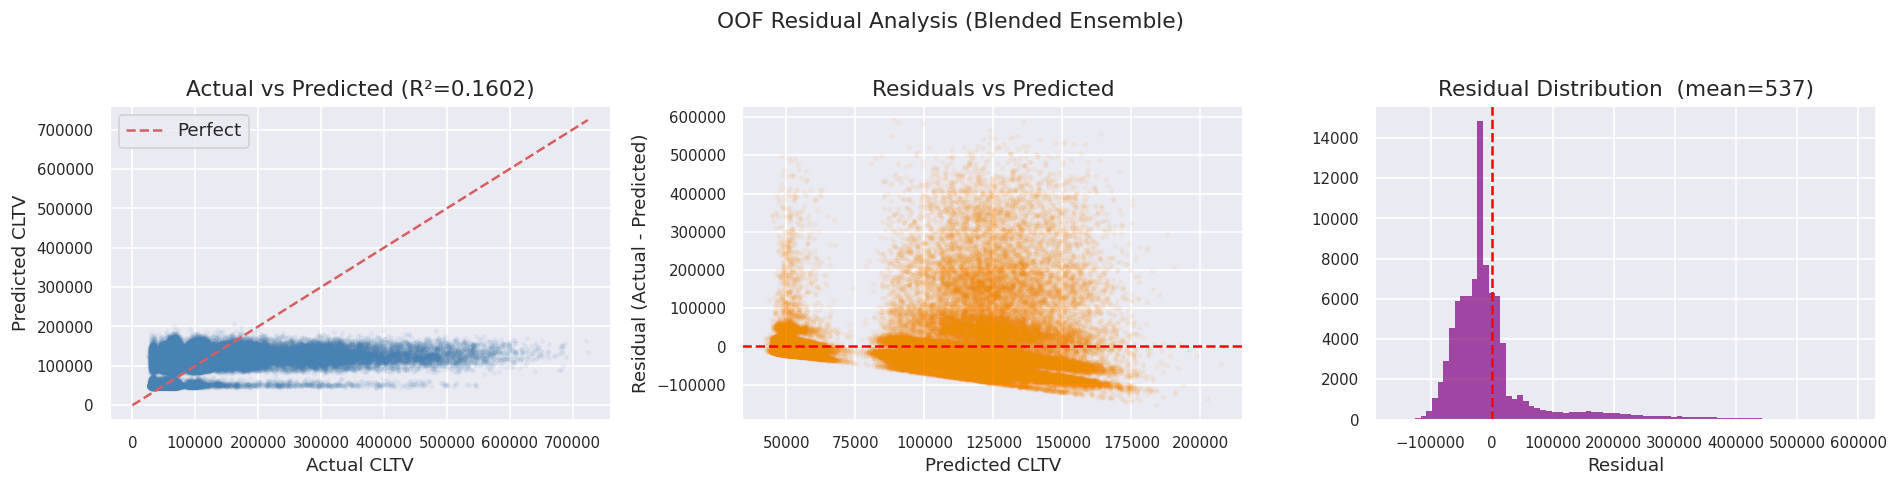

Mean Absolute Error (MAE) : 50,226
Root Mean Sq Error (RMSE): 83,039
OOF R² (original scale)  : 0.16019


In [274]:
y_orig    = y_raw.values                 # ← was np.expm1(y_log)
pred_orig = oof_blend                    # ← was np.expm1(oof_blend)
residuals = y_orig - pred_orig

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Plot 1: Actual vs Predicted
axes[0].scatter(y_orig, pred_orig, alpha=0.05, s=5, color='steelblue')
max_val = max(y_orig.max(), pred_orig.max())
axes[0].plot([0, max_val], [0, max_val], 'r--', lw=1.5, label='Perfect')
axes[0].set_xlabel('Actual CLTV')
axes[0].set_ylabel('Predicted CLTV')
axes[0].set_title(f'Actual vs Predicted (R²={blend_r2:.4f})')
axes[0].legend()

# Plot 2: Residuals vs Predicted
axes[1].scatter(pred_orig, residuals, alpha=0.05, s=5, color='darkorange')
axes[1].axhline(0, color='red', lw=1.5, ls='--')
axes[1].set_xlabel('Predicted CLTV')
axes[1].set_ylabel('Residual (Actual - Predicted)')
axes[1].set_title('Residuals vs Predicted')

# Plot 3: Residual distribution
axes[2].hist(residuals, bins=80, color='purple', alpha=0.7, edgecolor='none')
axes[2].axvline(0, color='red', lw=1.5, ls='--')
axes[2].set_xlabel('Residual')
axes[2].set_title(f'Residual Distribution  (mean={residuals.mean():,.0f})')

plt.suptitle('OOF Residual Analysis (Blended Ensemble)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print(f'Mean Absolute Error (MAE) : {np.abs(residuals).mean():,.0f}')
print(f'Root Mean Sq Error (RMSE): {np.sqrt((residuals**2).mean()):,.0f}')
print(f'OOF R² (original scale)  : {blend_r2:.5f}')

### ***7.8 Feature Importance (LightGBM)***

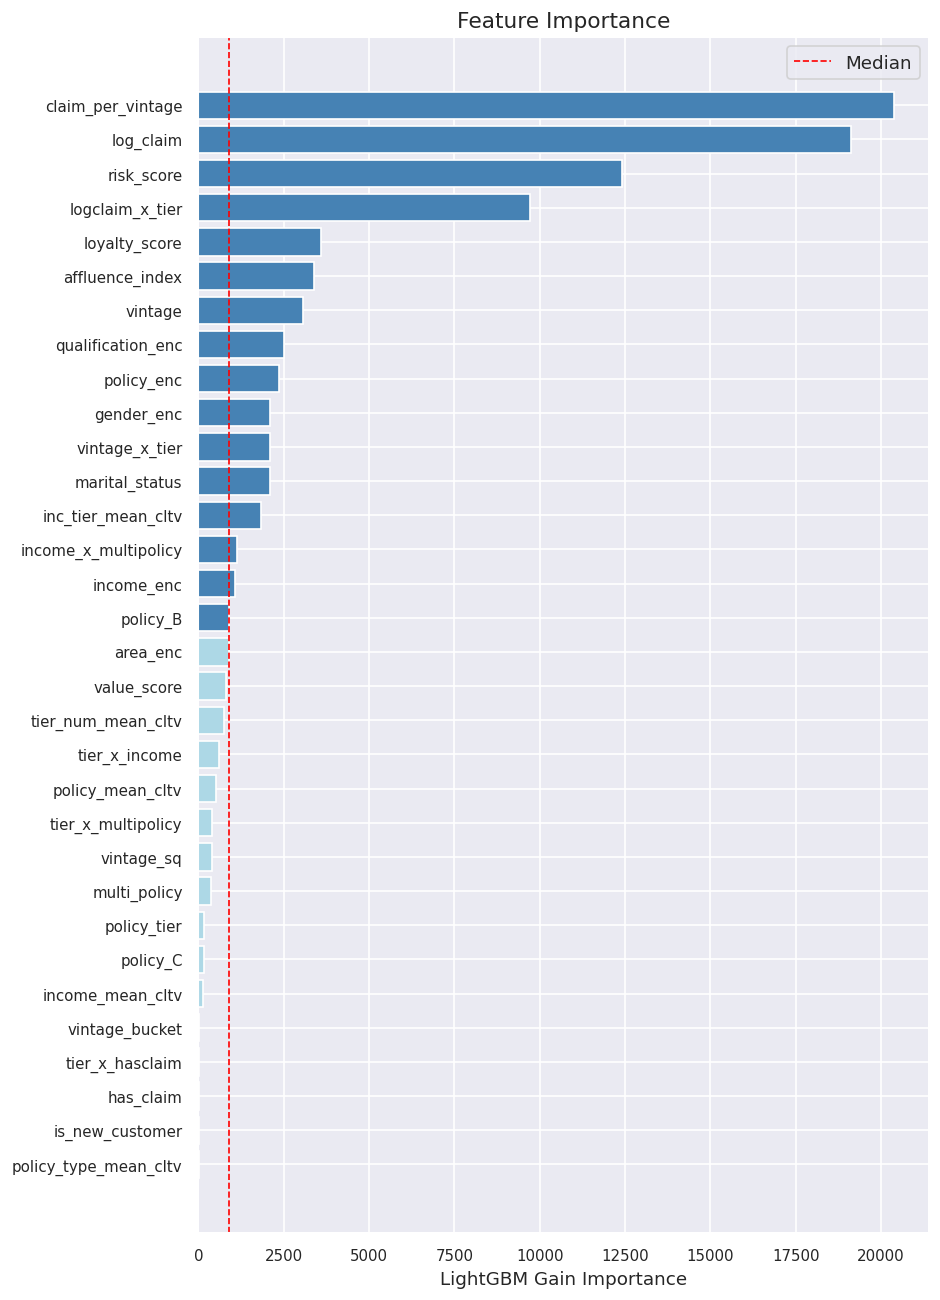

Top 10 features:
          feature  importance
claim_per_vintage       20384
        log_claim       19131
       risk_score       12405
  logclaim_x_tier        9725
    loyalty_score        3587
  affluence_index        3378
          vintage        3074
qualification_enc        2508
       policy_enc        2352
       gender_enc        2109

Low-importance features (< 10): ['policy_type_mean_cltv', 'is_new_customer']


In [275]:
# Retrain on full data — importance only, not for submission
final_lgb = lgb.LGBMRegressor(**{**lgb_params, 'n_estimators': 1500})
final_lgb.fit(X_train, y_log)

imp_df = pd.DataFrame({
    'feature'   : FEATURES,
    'importance': final_lgb.feature_importances_
}).sort_values('importance', ascending=True).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(8, 11))
colors = ['steelblue' if v > imp_df['importance'].median() else 'lightblue'
          for v in imp_df['importance']]
ax.barh(imp_df['feature'], imp_df['importance'], color=colors)
ax.axvline(imp_df['importance'].median(), color='red', ls='--', lw=1, label='Median')
ax.set_xlabel('LightGBM Gain Importance')
ax.set_title('Feature Importance')
ax.legend()
plt.tight_layout()
plt.show()

print('Top 10 features:')
print(imp_df.tail(10)[['feature','importance']].iloc[::-1].to_string(index=False))

# Identify near-zero importance features (candidates for removal)
low_imp = imp_df[imp_df['importance'] < 10]['feature'].tolist()
print(f'\nLow-importance features (< 10): {low_imp}')

### ***7.9 Final Submission File***

In [277]:
final_preds = test_blend

cltv_min = y_raw.min()
cltv_max = y_raw.max()
final_preds = np.clip(final_preds, cltv_min, cltv_max)

submission = pd.DataFrame({
    'id'  : test_ids.values,
    'cltv': final_preds
})

print(f'Submission shape: {submission.shape}')
print(f'Predicted CLTV — min: {final_preds.min():,.0f}  max: {final_preds.max():,.0f}  mean: {final_preds.mean():,.0f}')
print(submission.head(10).to_string(index=False))

submission.to_csv(DATA + 'submission_v2.csv', index=False)
print('\n  submission_v2.csv saved!')

Submission shape: (59595, 2)
Predicted CLTV — min: 43,856  max: 192,746  mean: 97,602
   id          cltv
89393  91278.363563
89394 128192.266792
89395  94411.953408
89396  87291.164603
89397 135000.803718
89398 114581.720444
89399  49446.165086
89400 106167.040245
89401  48369.422190
89402 152781.172879

  submission_v2.csv saved!
